In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/datasets/mimi

# MODMA Dot-probe — Resting-style LOSO-CV v3
## 384 windows/subject · TCN · CNN · CNN+LSTM · TCN+FFNN · Reviewer-3 biomarkers

This version addresses the failure pattern seen in the previous dot-probe run:

- TCN: all 34 subjects classified as MDD, specificity = 0%, AUC ≈ 0.44.
- CNN: almost all subjects classified as MDD, specificity = 10%, AUC ≈ 0.48.

Those results are not primarily a `0.50` threshold problem: ROC-AUC is threshold
independent. The important problem is weak / reversed **subject-level ranking** plus
strong class bias.

This notebook therefore follows the **resting-state model structure and model-selection
logic**, while keeping dot-probe runtime practical.

### Final four models

1. **TCN**
2. **CNN**
3. **CNN + LSTM**
4. **TCN + FFNN**

### Main changes versus the low-AUC dot-probe notebook

- keeps **384 temporally distributed windows per participant**;
- uses the resting-state architecture topology (LayerNorm, residual TCN blocks,
  global average + max pooling, compact FFNN heads);
- uses **full subject-level class balancing** rather than tempered balancing;
- uses a subject-wise inner validation split;
- inner epoch selection emphasizes **subject-level ROC-AUC**;
- inner threshold calibration is performed only on inner-validation subjects;
- selector training uses only **96 uniformly distributed windows/subject** for speed;
- after epoch/threshold selection, the model is **reinitialized and retrained on
  all non-test subjects using all 384 windows/subject**;
- the outer held-out participant is used only once for final evaluation;
- mixed precision + large batches + short epoch caps target practical Kaggle GPU time;
- every completed LOSO fold is checkpointed and can resume;
- a 52-minute safety guard prevents one invocation from consuming open-ended GPU time.

### Important scientific note

This code is designed to improve the training/evaluation procedure; it does **not**
force ROC-AUC upward. If strict LOSO AUC remains near chance after these corrections,
that result should be reported rather than post-hoc flipping probabilities or tuning
against held-out subjects.

Dot-probe windows are treated as **task-related EEG windows**, not as named ERP
components unless reliable event markers and event-locking are available.

In [8]:
# ==============================================================
# CELL 1 — Imports / GPU setup / reproducibility
# ==============================================================

import os
import re
import gc
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal, stats

from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GPUS = tf.config.list_physical_devices("GPU")

for gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

if GPUS:
    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
    except Exception as exc:
        print("Mixed precision setup warning:", exc)
else:
    print("WARNING: no GPU detected. This notebook is optimized for Kaggle GPU.")

print("TensorFlow:", tf.__version__)
print("GPU(s):", GPUS)
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())

TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


## Setup, Save, and 384-window LOSO-ready dot-probe cache
Run once. This uses the same segment-safe 250→125 Hz cache logic as the previous dot-probe notebook.

In [9]:
# ============================================================
# SETUP, SAVE, AND PREPARE LOSO-READY CACHE
# DOT-PROBE RESTING-STYLE v3 — SEGMENT-SAFE + 250 -> 125 Hz + SUBJECT-BALANCED
# ============================================================

PARADIGM = "Dot-probe"

DATA_DIR = Path(
    "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/"
    "raw-csv-actual/raw-csv-actual/csv_from_raw1"
)

OUTPUT_ROOT = Path("/kaggle/working/LOSO_Q1_dotprobe")
RESULTS_ROOT = OUTPUT_ROOT / "model_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

ORIGINAL_FS = 250.0
DOWNSAMPLE_FACTOR = 2
FS = ORIGINAL_FS / DOWNSAMPLE_FACTOR
WINDOW_SIZE = 125
STRIDE = 62
MAX_WINDOWS_PER_SUBJECT = 384

cap_tag = "ALL" if MAX_WINDOWS_PER_SUBJECT is None else str(MAX_WINDOWS_PER_SUBJECT)
CACHE_PATH = OUTPUT_ROOT / f"dotprobe_GPUFAST_raw_125Hz_{cap_tag}w_per_subject.npz"
LABEL_NAMES = {0: "HC", 1: "MDD"}

print("DATA_DIR:", DATA_DIR)
print("CACHE_PATH:", CACHE_PATH)
print("FS:", FS, "WINDOW_SIZE:", WINDOW_SIZE, "STRIDE:", STRIDE)


def parse_subject_label(filename):
    m = re.search(r"(020[123])[-_]?(\d+)", Path(filename).stem)
    if not m:
        return None, None, None
    code = m.group(1)
    subject = f"{code}_{m.group(2)}"
    if code == "0201":
        return subject, 1, code
    if code == "0203":
        return subject, 0, code
    return subject, None, code


def detect_eeg_columns(columns):
    found = {}
    for col in columns:
        m = re.match(r"^(?:EEG[\s_-]*|E[\s_-]*)(\d{1,3})$", str(col).strip(), re.I)
        if m:
            n = int(m.group(1))
            if 1 <= n <= 128:
                found[n] = col
    if len(found) < 100:
        raise ValueError(f"Only {len(found)} EEG columns found. First columns: {list(columns)[:15]}")
    return [found[k] for k in sorted(found)]


def available_window_starts(n_samples, window_size, stride):
    if n_samples < window_size:
        return np.array([], dtype=int)
    return np.arange(0, n_samples-window_size+1, stride, dtype=int)


def extract_selected_windows(arr, starts, window_size):
    if len(starts) == 0:
        return np.empty((0, window_size, arr.shape[1]), dtype=np.float32)
    return np.stack([arr[s:s+window_size] for s in starts], axis=0).astype(np.float32)


def validate_groups(y, groups):
    for subject in np.unique(groups):
        labs = np.unique(y[groups == subject])
        assert len(labs) == 1, (subject, labs)


def make_subject_table(X, y, groups):
    subjects = np.unique(groups)
    d = pd.DataFrame({
        "subject": subjects,
        "label": [int(y[groups == s][0]) for s in subjects],
        "diagnosis": [LABEL_NAMES[int(y[groups == s][0])] for s in subjects],
        "n_windows": [int(np.sum(groups == s)) for s in subjects]
    })
    print("\nX shape:", X.shape)
    print("Subjects:", len(d))
    print("Subject-level class counts:")
    print(d["diagnosis"].value_counts())
    display(d)
    return d


if CACHE_PATH.exists():
    z = np.load(CACHE_PATH, allow_pickle=True)
    X = z["X"].astype(np.float32)
    y = z["y"].astype(np.int8)
    groups = z["groups"].astype(str)
    channel_names = z["channel_names"].astype(str)
    print("Loaded existing dot-probe LOSO cache:", CACHE_PATH)
else:
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

    subject_files = defaultdict(list)
    subject_labels = {}

    for path in csv_files:
        subject, label, code = parse_subject_label(path.name)
        if label is None:  # excludes 0202
            continue
        subject_files[subject].append(path)
        subject_labels[subject] = int(label)

    print("Binary subjects discovered:", len(subject_files))

    X_parts, y_parts, group_parts = [], [], []
    channel_names = None

    for subject_i, subject in enumerate(sorted(subject_files), start=1):
        segment_info = []

        # Pass 1: legal window positions after 2x downsampling.
        for path in subject_files[subject]:
            df = pd.read_csv(path)
            eeg_cols = detect_eeg_columns(df.columns)
            if channel_names is None:
                channel_names = np.asarray([str(c) for c in eeg_cols], dtype=str)
            if len(eeg_cols) != len(channel_names):
                raise ValueError(f"{path.name}: {len(eeg_cols)} channels != {len(channel_names)}")

            n_ds = int(np.ceil(len(df) / DOWNSAMPLE_FACTOR))
            starts = available_window_starts(n_ds, WINDOW_SIZE, STRIDE)
            segment_info.append({
                "path": path,
                "eeg_cols": eeg_cols,
                "starts": starts,
                "n_windows": len(starts)
            })
            del df
            gc.collect()

        total_available = sum(info["n_windows"] for info in segment_info)
        if total_available == 0:
            print("Skipping", subject, "- no legal windows")
            continue

        n_keep = total_available if MAX_WINDOWS_PER_SUBJECT is None else min(MAX_WINDOWS_PER_SUBJECT, total_available)
        selected_global = np.linspace(0, total_available-1, n_keep, dtype=int)

        selected_windows = []
        cumulative_start = 0

        # Pass 2: load/downsample only segments containing selected windows.
        for info in segment_info:
            n_seg = info["n_windows"]
            cumulative_end = cumulative_start + n_seg
            mask = (selected_global >= cumulative_start) & (selected_global < cumulative_end)
            selected_local = selected_global[mask] - cumulative_start

            if len(selected_local):
                df = pd.read_csv(info["path"])
                arr = (
                    df[info["eeg_cols"]]
                    .apply(pd.to_numeric, errors="coerce")
                    .to_numpy(dtype=np.float32)
                )
                arr_ds = signal.resample_poly(
                    arr, up=1, down=DOWNSAMPLE_FACTOR, axis=0
                ).astype(np.float32)
                actual_starts = info["starts"][selected_local]
                w = extract_selected_windows(arr_ds, actual_starts, WINDOW_SIZE)
                selected_windows.append(w)
                del df, arr, arr_ds, w
                gc.collect()

            cumulative_start = cumulative_end

        subject_X = np.concatenate(selected_windows, axis=0).astype(np.float32)
        assert len(subject_X) == n_keep, (subject, len(subject_X), n_keep)
        label = subject_labels[subject]

        X_parts.append(subject_X)
        y_parts.append(np.full(len(subject_X), label, dtype=np.int8))
        group_parts.append(np.full(len(subject_X), subject, dtype=object))

        print(
            f"{subject_i:02d} | {subject:12s} | {LABEL_NAMES[label]:3s} | "
            f"available={total_available:5d} | kept={len(subject_X):3d} | "
            f"files={len(subject_files[subject])}"
        )

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts).astype(np.int8)
    groups = np.concatenate(group_parts).astype(str)
    channel_names = np.asarray(channel_names, dtype=str)

    assert len(X) == len(y) == len(groups)
    validate_groups(y, groups)

    logo = LeaveOneGroupOut()
    n_folds = 0
    for train_idx, test_idx in logo.split(X, y, groups):
        assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
        assert len(set(groups[test_idx])) == 1
        n_folds += 1

    print("Verified LOSO folds:", n_folds)
    print("No subject leakage detected.")

    np.savez_compressed(
        CACHE_PATH,
        X=X,
        y=y,
        groups=groups,
        channel_names=channel_names,
        fs=np.asarray(FS, dtype=np.float32),
        original_fs=np.asarray(ORIGINAL_FS, dtype=np.float32),
        downsample_factor=np.asarray(DOWNSAMPLE_FACTOR, dtype=np.int16),
        max_windows_per_subject=np.asarray(
            -1 if MAX_WINDOWS_PER_SUBJECT is None else MAX_WINDOWS_PER_SUBJECT,
            dtype=np.int32
        )
    )
    print("Saved LOSO-ready dot-probe cache:", CACHE_PATH)

subject_table = make_subject_table(X, y, groups)

logo = LeaveOneGroupOut()
n_folds = 0
for train_idx, test_idx in logo.split(X, y, groups):
    assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))
    assert len(set(groups[test_idx])) == 1
    n_folds += 1

print("LOSO folds:", n_folds)
print("No subject leakage detected.")
if CACHE_PATH.exists():
    print("Compressed cache size:", f"{CACHE_PATH.stat().st_size / (1024**2):.1f} MiB")

DATA_DIR: /kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/raw-csv-actual/raw-csv-actual/csv_from_raw1
CACHE_PATH: /kaggle/working/LOSO_Q1_dotprobe/dotprobe_GPUFAST_raw_125Hz_384w_per_subject.npz
FS: 125.0 WINDOW_SIZE: 125 STRIDE: 62
Loaded existing dot-probe LOSO cache: /kaggle/working/LOSO_Q1_dotprobe/dotprobe_GPUFAST_raw_125Hz_384w_per_subject.npz

X shape: (13056, 125, 128)
Subjects: 34
Subject-level class counts:
diagnosis
MDD    24
HC     10
Name: count, dtype: int64


,subject,label,diagnosis,n_windows
0,0201_0002,1,MDD,384
1,0201_0004,1,MDD,384
2,0201_0005,1,MDD,384
3,0201_0006,1,MDD,384
4,0201_0008,1,MDD,384
5,0201_0010,1,MDD,384
6,0201_0011,1,MDD,384
7,0201_0012,1,MDD,384
8,0201_0013,1,MDD,384
9,0201_0015,1,MDD,384


LOSO folds: 34
No subject leakage detected.
Compressed cache size: 740.8 MiB


## Pre-flight sanity check

In [10]:
# ==============================================================
# PRE-FLIGHT LABEL / CACHE CHECK
# ==============================================================

assert MAX_WINDOWS_PER_SUBJECT == 384, (
    "This v3 notebook is designed for exactly 384 windows/subject. "
    f"Current value = {MAX_WINDOWS_PER_SUBJECT}"
)

assert set(np.unique(y)).issubset({0, 1})

subject_check = (
    pd.DataFrame({
        "subject": np.unique(groups)
    })
)

subject_check["label"] = [
    int(y[groups == s][0])
    for s in subject_check["subject"]
]

subject_check["diagnosis"] = subject_check["label"].map(LABEL_NAMES)

# Filename-code sanity check.
for _, row in subject_check.iterrows():
    s = str(row["subject"])
    lab = int(row["label"])

    if s.startswith("0201"):
        assert lab == 1, (s, lab)

    if s.startswith("0203"):
        assert lab == 0, (s, lab)

print("X:", X.shape)
print("Subjects:", len(subject_check))
print(subject_check["diagnosis"].value_counts())
print("Windows / subject:")
print(pd.Series(groups).value_counts().describe())

display(subject_check)

X: (13056, 125, 128)
Subjects: 34
diagnosis
MDD    24
HC     10
Name: count, dtype: int64
Windows / subject:
count     34.0
mean     384.0
std        0.0
min      384.0
25%      384.0
50%      384.0
75%      384.0
max      384.0
Name: count, dtype: float64


,subject,label,diagnosis
0,0201_0002,1,MDD
1,0201_0004,1,MDD
2,0201_0005,1,MDD
3,0201_0006,1,MDD
4,0201_0008,1,MDD
5,0201_0010,1,MDD
6,0201_0011,1,MDD
7,0201_0012,1,MDD
8,0201_0013,1,MDD
9,0201_0015,1,MDD


## Shared resting-style v3 LOSO engine
Run once before any model cell.

In [11]:
# ======================================================================
# SHARED RESTING-STYLE v3 LOSO ENGINE — DOT-PROBE
#
# Key speed idea:
#   selector = 96 uniformly distributed windows/subject
#   final model = all 384 windows/subject
#
# This gives subject-level epoch/threshold selection without paying for
# two full 384-window training jobs in every LOSO fold.
# ======================================================================

DP3_SEED = 42
DP3_INNER_VAL_FRACTION = 0.30

# Small selector subset; final training still uses all 384.
DP3_SELECTOR_WINDOWS_PER_SUBJECT = 96

# Full subject-level balance is deliberate for the 24 MDD / ~10 HC task cohort.
DP3_CLASS_WEIGHT_POWER = 1.00

DP3_TRIM_FRACTION = 0.10

DP3_WEIGHT_DECAY = 1e-4

# Previous dot-probe models were strongly biased toward MDD.
# No label smoothing here so minority-class separation is not softened.
DP3_LABEL_SMOOTHING = 0.00

DP3_PRED_BATCH_SIZE = 128

# Threshold calibration only affects class decisions, not ROC-AUC.
DP3_THRESHOLD_GRID = np.arange(0.35, 0.651, 0.01)
DP3_THRESHOLD_DISTANCE_PENALTY = 0.04

# Stop before starting another fold if one invocation is approaching an hour.
DP3_MAX_CALL_MINUTES = 52.0

DP3_FOLD_LIMIT = None

DP3_ROOT = (
    Path(RESULTS_ROOT)
    /
    "DotProbe_RestingStyle_384w_Final4_v3"
)

DP3_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_DOTPROBE_MODELS = [
    "TCN",
    "CNN",
    "CNN+LSTM",
    "TCN+FFNN",
]

print("Result root:", DP3_ROOT)
print("Selector windows / subject:", DP3_SELECTOR_WINDOWS_PER_SUBJECT)
print("Final windows / subject:", MAX_WINDOWS_PER_SUBJECT)
print("Inner validation fraction:", DP3_INNER_VAL_FRACTION)
print("Class-weight power:", DP3_CLASS_WEIGHT_POWER)
print("Runtime guard:", DP3_MAX_CALL_MINUTES, "minutes")


# ======================================================================
# 1. SUBJECT-WISE INNER SPLIT
# ======================================================================

def dp3_inner_subject_split(
    outer_train_idx,
    y,
    groups,
    seed
):
    subjects = np.unique(
        groups[
            outer_train_idx
        ]
    )

    subject_labels = np.asarray(
        [
            int(
                y[
                    groups == s
                ][0]
            )
            for s in subjects
        ],
        dtype=int
    )

    train_subjects, val_subjects = train_test_split(
        subjects,
        test_size=DP3_INNER_VAL_FRACTION,
        random_state=seed,
        stratify=subject_labels
    )

    train_idx = outer_train_idx[
        np.isin(
            groups[
                outer_train_idx
            ],
            train_subjects
        )
    ]

    val_idx = outer_train_idx[
        np.isin(
            groups[
                outer_train_idx
            ],
            val_subjects
        )
    ]

    return train_idx, val_idx


# ======================================================================
# 2. UNIFORM PER-SUBJECT SUBSET FOR FAST INNER SELECTION
# ======================================================================

def dp3_uniform_subject_subset(
    indices,
    groups,
    max_windows
):
    selected = []

    local_groups = groups[
        indices
    ]

    for subject in np.unique(
        local_groups
    ):
        idx = indices[
            local_groups == subject
        ]

        if len(idx) > max_windows:
            idx = idx[
                np.linspace(
                    0,
                    len(idx) - 1,
                    max_windows,
                    dtype=int
                )
            ]

        selected.append(
            idx
        )

    return np.concatenate(
        selected
    ).astype(
        int
    )


# ======================================================================
# 3. FOLD-ONLY CHANNEL STANDARDIZATION
#
# Unlike resting-state v3 temporal demeaning, dot-probe v3 preserves
# task-related window amplitude/offset structure and uses ONLY training
# subjects to estimate channel mean/SD.
# ======================================================================

def dp3_fit_preprocessor(
    X_train_raw
):
    X = np.asarray(
        X_train_raw,
        dtype=np.float32
    )

    flat = X.reshape(
        -1,
        X.shape[-1]
    ).astype(
        np.float64
    )

    channel_mean = np.nanmean(
        flat,
        axis=0
    )

    channel_mean = np.where(
        np.isfinite(channel_mean),
        channel_mean,
        0.0
    ).astype(
        np.float32
    )

    channel_sd = np.nanstd(
        flat,
        axis=0
    )

    channel_sd = np.where(
        (
            np.isfinite(channel_sd)
        )
        &
        (
            channel_sd >= 1e-7
        ),
        channel_sd,
        1.0
    ).astype(
        np.float32
    )

    return channel_mean, channel_sd


def dp3_transform(
    X_raw,
    channel_mean,
    channel_sd
):
    X = np.asarray(
        X_raw,
        dtype=np.float32
    ).copy()

    for c in range(
        X.shape[-1]
    ):
        bad = ~np.isfinite(
            X[..., c]
        )

        if np.any(bad):
            X[..., c][bad] = channel_mean[c]

    X = (
        X
        -
        channel_mean[
            None,
            None,
            :
        ]
    ) / channel_sd[
        None,
        None,
        :
    ]

    X = np.clip(
        X,
        -6.0,
        6.0
    )

    return np.nan_to_num(
        X,
        nan=0.0,
        posinf=6.0,
        neginf=-6.0
    ).astype(
        np.float32
    )


# ======================================================================
# 4. FULL SUBJECT-LEVEL CLASS BALANCE
# ======================================================================

def dp3_subject_class_weights(
    y_train,
    groups_train
):
    subjects = np.unique(
        groups_train
    )

    subject_labels = np.asarray(
        [
            int(
                y_train[
                    groups_train == s
                ][0]
            )
            for s in subjects
        ],
        dtype=int
    )

    classes = np.asarray(
        [0, 1],
        dtype=int
    )

    raw = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=subject_labels
    )

    weights = np.power(
        raw,
        DP3_CLASS_WEIGHT_POWER
    )

    weights /= np.mean(
        weights
    )

    return {
        int(c): float(w)
        for c, w in zip(
            classes,
            weights
        )
    }


# ======================================================================
# 5. ROBUST WINDOW -> SUBJECT PROBABILITY
# ======================================================================

def dp3_trimmed_mean(
    values,
    trim_fraction=DP3_TRIM_FRACTION
):
    a = np.sort(
        np.asarray(
            values,
            dtype=float
        )
    )

    if len(a) == 0:
        return np.nan

    k = int(
        np.floor(
            trim_fraction
            *
            len(a)
        )
    )

    if (
        k > 0
        and
        2*k < len(a)
    ):
        a = a[
            k:-k
        ]

    return float(
        np.mean(
            a
        )
    )


def dp3_subject_table(
    prob,
    y,
    groups
):
    rows = []

    for subject in np.unique(
        groups
    ):
        mask = (
            groups
            ==
            subject
        )

        rows.append(
            {
                "subject": str(subject),
                "label": int(y[mask][0]),
                "prob": dp3_trimmed_mean(
                    prob[mask]
                ),
                "n_windows": int(
                    np.sum(mask)
                )
            }
        )

    return pd.DataFrame(
        rows
    )


# ======================================================================
# 6. INNER-VALIDATION THRESHOLD
# ======================================================================

def dp3_calibrate_threshold(
    subject_df
):
    yt = subject_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    pr = subject_df[
        "prob"
    ].to_numpy(
        dtype=float
    )

    if len(
        np.unique(yt)
    ) < 2:
        return 0.50, np.nan, np.nan

    balanced_scores = []
    regularized_scores = []

    for threshold in DP3_THRESHOLD_GRID:
        pred = (
            pr >= threshold
        ).astype(
            int
        )

        bal = balanced_accuracy_score(
            yt,
            pred
        )

        regularized = (
            bal
            -
            DP3_THRESHOLD_DISTANCE_PENALTY
            *
            abs(
                float(threshold)
                -
                0.50
            )
        )

        balanced_scores.append(
            bal
        )

        regularized_scores.append(
            regularized
        )

    balanced_scores = np.asarray(
        balanced_scores,
        dtype=float
    )

    regularized_scores = np.asarray(
        regularized_scores,
        dtype=float
    )

    best = np.flatnonzero(
        np.isclose(
            regularized_scores,
            regularized_scores.max()
        )
    )

    chosen = best[
        np.argmin(
            np.abs(
                DP3_THRESHOLD_GRID[
                    best
                ]
                -
                0.50
            )
        )
    ]

    return (
        float(
            DP3_THRESHOLD_GRID[
                chosen
            ]
        ),
        float(
            balanced_scores[
                chosen
            ]
        ),
        float(
            regularized_scores[
                chosen
            ]
        )
    )


# ======================================================================
# 7. LOW-OVERHEAD PREDICTION
# ======================================================================

def dp3_fast_predict(
    model,
    X,
    batch_size=DP3_PRED_BATCH_SIZE
):
    pieces = []

    for start in range(
        0,
        len(X),
        batch_size
    ):
        xb = tf.convert_to_tensor(
            X[
                start:
                start
                +
                batch_size
            ],
            dtype=tf.float32
        )

        pieces.append(
            model(
                xb,
                training=False
            )
            .numpy()
            .ravel()
        )

    return np.concatenate(
        pieces
    )


# ======================================================================
# 8. SUBJECT-AUC MODEL SELECTION
# ======================================================================

class DP3SubjectValidation(
    callbacks.Callback
):
    def __init__(
        self,
        X_val,
        y_val,
        groups_val,
        min_epochs,
        patience
    ):
        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.groups_val = groups_val

        self.min_epochs = int(
            min_epochs
        )

        self.patience = int(
            patience
        )

        self.best_score = -np.inf
        self.best_epoch = 1
        self.best_threshold = 0.50
        self.best_auc = np.nan
        self.best_balanced_accuracy = np.nan
        self.wait = 0
        self.rows = []

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        prob = dp3_fast_predict(
            self.model,
            self.X_val
        )

        subject_df = dp3_subject_table(
            prob,
            self.y_val,
            self.groups_val
        )

        yt = subject_df[
            "label"
        ].to_numpy(
            dtype=int
        )

        pr = subject_df[
            "prob"
        ].to_numpy(
            dtype=float
        )

        auc = (
            roc_auc_score(
                yt,
                pr
            )
            if len(
                np.unique(yt)
            ) == 2
            else np.nan
        )

        threshold, bal, threshold_score = dp3_calibrate_threshold(
            subject_df
        )

        # Ranking is the main problem in the previous run,
        # so AUC dominates epoch selection.
        if np.isfinite(
            auc
        ):
            score = (
                0.90
                *
                auc
                +
                0.10
                *
                threshold_score
            )
        else:
            score = threshold_score

        self.rows.append(
            {
                "epoch": int(
                    epoch + 1
                ),
                "subject_auc": float(
                    auc
                ),
                "subject_balanced_accuracy": float(
                    bal
                ),
                "threshold": float(
                    threshold
                ),
                "selection_score": float(
                    score
                ),
                "window_val_loss": float(
                    logs.get(
                        "val_loss",
                        np.nan
                    )
                    if logs
                    else np.nan
                )
            }
        )

        print(
            f"  inner epoch {epoch+1:02d} | "
            f"subject AUC={auc:.3f} | "
            f"BalAcc={bal:.3f} | "
            f"thr={threshold:.2f}"
        )

        if (
            score
            >
            self.best_score
            +
            1e-4
        ):
            self.best_score = float(
                score
            )

            self.best_epoch = int(
                epoch + 1
            )

            self.best_threshold = float(
                threshold
            )

            self.best_auc = float(
                auc
            )

            self.best_balanced_accuracy = float(
                bal
            )

            self.wait = 0

        else:
            self.wait += 1

        if (
            epoch + 1 >= self.min_epochs
            and
            self.wait >= self.patience
        ):
            self.model.stop_training = True


# ======================================================================
# 9. COMPILE
# ======================================================================

def dp3_compile(
    model,
    learning_rate
):
    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=DP3_WEIGHT_DECAY,
            clipnorm=1.0
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        )

    model.compile(
        optimizer=optimizer,

        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=DP3_LABEL_SMOOTHING
        ),

        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ],

        steps_per_execution=16
    )

    return model


# ======================================================================
# 10. WILSON CI
# ======================================================================

def dp3_wilson(
    k,
    n,
    z=1.96
):
    if n == 0:
        return np.nan, np.nan

    p = k / n

    den = (
        1
        +
        z*z/n
    )

    centre = (
        p
        +
        z*z/(2*n)
    ) / den

    half = (
        z
        *
        np.sqrt(
            (
                p*(1-p)
                +
                z*z/(4*n)
            )
            /
            n
        )
        /
        den
    )

    return (
        float(
            max(
                0.0,
                centre-half
            )
        ),
        float(
            min(
                1.0,
                centre+half
            )
        )
    )


def dp3_safe_name(
    model_name
):
    return (
        model_name
        .replace(
            "+",
            "_"
        )
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )


# ======================================================================
# 11. REVIEWER PLOTS
# ======================================================================

def dp3_save_plots(
    folds_df,
    summary_df,
    model_dir,
    model_name
):
    safe = dp3_safe_name(
        model_name
    )

    s = summary_df.iloc[
        0
    ]

    rows = [
        [
            "LOSO subject accuracy",
            f"{100*s['LOSO_subject_accuracy']:.2f}%"
        ],
        [
            "Accuracy 95% CI",
            f"{100*s['accuracy_CI95_low']:.2f}%–"
            f"{100*s['accuracy_CI95_high']:.2f}%"
        ],
        [
            "Sensitivity (MDD)",
            f"{100*s['sensitivity_MDD']:.2f}%"
        ],
        [
            "Sensitivity 95% CI",
            f"{100*s['sensitivity_CI95_low']:.2f}%–"
            f"{100*s['sensitivity_CI95_high']:.2f}%"
        ],
        [
            "Specificity (HC)",
            f"{100*s['specificity_HC']:.2f}%"
        ],
        [
            "Specificity 95% CI",
            f"{100*s['specificity_CI95_low']:.2f}%–"
            f"{100*s['specificity_CI95_high']:.2f}%"
        ],
        [
            "Balanced accuracy",
            f"{100*s['balanced_accuracy']:.2f}%"
        ],
        [
            "MDD F1",
            f"{s['F1_MDD']:.3f}"
        ],
        [
            "Subject AUC",
            f"{s['subject_ROC_AUC']:.3f}"
        ],
        [
            "Mean P(MDD), HC",
            f"{s['mean_subject_prob_HC']:.3f}"
        ],
        [
            "Mean P(MDD), MDD",
            f"{s['mean_subject_prob_MDD']:.3f}"
        ],
        [
            "Fold window accuracy mean",
            f"{100*s['heldout_window_accuracy_mean']:.2f}%"
        ],
        [
            "Fold window accuracy SD",
            f"{100*s['heldout_window_accuracy_SD']:.2f}%"
        ]
    ]

    fig, ax = plt.subplots(
        figsize=(
            8.8,
            6.5
        )
    )

    ax.axis(
        "off"
    )

    tab = ax.table(
        cellText=rows,
        colLabels=[
            "Reviewer parameter",
            "LOSO result"
        ],
        loc="center",
        cellLoc="left"
    )

    tab.auto_set_font_size(
        False
    )

    tab.set_fontsize(
        9.5
    )

    tab.scale(
        1,
        1.38
    )

    ax.set_title(
        f"Dot-probe: {model_name} Resting-style LOSO-CV v3",
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_summary.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    yt = folds_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    yp = folds_df[
        "subject_pred"
    ].to_numpy(
        dtype=int
    )

    pr = folds_df[
        "subject_prob"
    ].to_numpy(
        dtype=float
    )


    cm = confusion_matrix(
        yt,
        yp,
        labels=[
            0,
            1
        ]
    )

    plt.figure(
        figsize=(
            5,
            4.5
        )
    )

    plt.imshow(
        cm
    )

    for (
        i,
        j
    ), value in np.ndenumerate(
        cm
    ):
        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=14
        )

    plt.xticks(
        [0, 1],
        ["HC", "MDD"]
    )

    plt.yticks(
        [0, 1],
        ["HC", "MDD"]
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.title(
        f"{model_name}: subject-level LOSO"
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    if len(
        np.unique(yt)
    ) == 2:
        fpr, tpr, _ = roc_curve(
            yt,
            pr
        )

        auc = roc_auc_score(
            yt,
            pr
        )

        plt.figure(
            figsize=(
                5,
                5
            )
        )

        plt.plot(
            fpr,
            tpr,
            label=f"AUC = {auc:.3f}"
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--"
        )

        plt.xlabel(
            "False positive rate"
        )

        plt.ylabel(
            "True positive rate"
        )

        plt.title(
            f"{model_name}: subject-level LOSO ROC"
        )

        plt.legend()

        plt.tight_layout()

        plt.savefig(
            model_dir
            /
            f"{safe}_LOSO_ROC.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()


    # Subject probability distribution — useful diagnostic for AUC / collapse.
    plt.figure(
        figsize=(
            6,
            4.5
        )
    )

    plt.boxplot(
        [
            folds_df.loc[
                folds_df["label"] == 0,
                "subject_prob"
            ],
            folds_df.loc[
                folds_df["label"] == 1,
                "subject_prob"
            ]
        ],
        tick_labels=[
            "HC",
            "MDD"
        ]
    )

    plt.axhline(
        0.50,
        linestyle="--",
        linewidth=1
    )

    plt.ylabel(
        "Held-out subject P(MDD)"
    )

    plt.title(
        f"{model_name}: LOSO probability separation"
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_subject_probability_separation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ======================================================================
# 12. NESTED-LITE LOSO RUNNER
# ======================================================================

def run_dp3_loso(
    model_name,
    build_model_fn,
    learning_rate,
    selector_max_epochs,
    selector_min_epochs,
    selector_patience,
    final_min_epochs,
    final_max_epochs,
    batch_size
):
    safe = dp3_safe_name(
        model_name
    )

    model_dir = (
        DP3_ROOT
        /
        safe
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    fold_csv = (
        model_dir
        /
        f"{safe}_LOSO_folds.csv"
    )

    summary_csv = (
        model_dir
        /
        f"{safe}_LOSO_summary.csv"
    )

    history_csv = (
        model_dir
        /
        f"{safe}_inner_subject_validation_history.csv"
    )


    if fold_csv.exists():
        folds_df = pd.read_csv(
            fold_csv
        )

        folds_df[
            "subject"
        ] = (
            folds_df[
                "subject"
            ]
            .astype(str)
            .str.strip()
        )

        completed = set(
            folds_df[
                "subject"
            ]
        )

        print(
            f"{model_name}: RESUME MODE — "
            f"{len(completed)} completed folds."
        )

    else:
        folds_df = pd.DataFrame()
        completed = set()

        print(
            f"{model_name}: NEW v3 RUN."
        )


    if history_csv.exists():
        history_all = pd.read_csv(
            history_csv
        )
    else:
        history_all = pd.DataFrame()


    logo = LeaveOneGroupOut()

    splits = list(
        logo.split(
            X,
            y,
            groups
        )
    )

    if DP3_FOLD_LIMIT is not None:
        splits = splits[
            :int(
                DP3_FOLD_LIMIT
            )
        ]

        print(
            "WARNING: DP3_FOLD_LIMIT active."
        )


    call_start = time.time()
    fold_durations = []


    for fold, (
        outer_train_idx,
        outer_test_idx
    ) in enumerate(
        splits,
        start=1
    ):

        test_subject = str(
            np.unique(
                groups[
                    outer_test_idx
                ]
            )[0]
        ).strip()


        if test_subject in completed:
            print(
                f"[resume skip] {model_name} "
                f"fold {fold:02d}/{len(splits):02d} "
                f"{test_subject}"
            )

            continue


        elapsed = (
            time.time()
            -
            call_start
        ) / 60.0


        if fold_durations:
            expected_next = max(
                2.0,
                1.25
                *
                float(
                    np.median(
                        fold_durations
                    )
                )
            )
        else:
            expected_next = 4.0


        if (
            elapsed
            +
            expected_next
            >
            DP3_MAX_CALL_MINUTES
        ):
            print(
                "\nRUNTIME GUARD: not starting another fold."
            )

            print(
                f"Elapsed: {elapsed:.1f} min"
            )

            print(
                f"Completed subjects safely saved: {len(completed)}"
            )

            print(
                "Rerun this SAME model cell to resume."
            )

            break


        fold_start = time.time()


        print(
            "\n"
            +
            "=" * 78
        )

        print(
            f"{model_name} OUTER FOLD "
            f"{fold:02d}/{len(splits):02d} "
            f"| held out={test_subject} "
            f"| true={LABEL_NAMES[int(y[outer_test_idx][0])]}"
        )

        print(
            "=" * 78
        )


        assert set(
            groups[
                outer_train_idx
            ]
        ).isdisjoint(
            set(
                groups[
                    outer_test_idx
                ]
            )
        )


        # ======================================================
        # A. INNER SUBJECT-WISE SELECTION — 96 WINDOWS/SUBJECT
        # ======================================================

        inner_train_full_idx, inner_val_full_idx = dp3_inner_subject_split(
            outer_train_idx,
            y,
            groups,
            seed=DP3_SEED + fold
        )


        inner_train_idx = dp3_uniform_subject_subset(
            inner_train_full_idx,
            groups,
            DP3_SELECTOR_WINDOWS_PER_SUBJECT
        )


        inner_val_idx = dp3_uniform_subject_subset(
            inner_val_full_idx,
            groups,
            DP3_SELECTOR_WINDOWS_PER_SUBJECT
        )


        X_itr_raw = X[
            inner_train_idx
        ]

        X_iva_raw = X[
            inner_val_idx
        ]

        y_itr = y[
            inner_train_idx
        ].astype(
            int
        )

        y_iva = y[
            inner_val_idx
        ].astype(
            int
        )

        g_itr = groups[
            inner_train_idx
        ]

        g_iva = groups[
            inner_val_idx
        ]


        inner_mean, inner_sd = dp3_fit_preprocessor(
            X_itr_raw
        )


        X_itr = dp3_transform(
            X_itr_raw,
            inner_mean,
            inner_sd
        )


        X_iva = dp3_transform(
            X_iva_raw,
            inner_mean,
            inner_sd
        )


        inner_weights = dp3_subject_class_weights(
            y_itr,
            g_itr
        )


        tf.keras.backend.clear_session()

        np.random.seed(
            DP3_SEED
            +
            fold
        )

        tf.random.set_seed(
            DP3_SEED
            +
            fold
        )


        selector_model = build_model_fn(
            (
                X_itr.shape[
                    1
                ],
                X_itr.shape[
                    2
                ]
            ),
            learning_rate
        )


        selector_cb = DP3SubjectValidation(
            X_iva,
            y_iva,
            g_iva,
            min_epochs=selector_min_epochs,
            patience=selector_patience
        )


        selector_model.fit(
            X_itr,
            y_itr,

            validation_data=(
                X_iva,
                y_iva
            ),

            epochs=selector_max_epochs,

            batch_size=batch_size,

            class_weight=inner_weights,

            shuffle=True,

            callbacks=[
                selector_cb,
                callbacks.TerminateOnNaN()
            ],

            verbose=0
        )


        threshold = float(
            selector_cb.best_threshold
        )


        final_epochs = int(
            np.clip(
                selector_cb.best_epoch,
                final_min_epochs,
                final_max_epochs
            )
        )


        print(
            "\nInner selection:"
        )

        print(
            "  best epoch:",
            selector_cb.best_epoch
        )

        print(
            "  final retrain epochs:",
            final_epochs
        )

        print(
            "  inner subject AUC:",
            f"{selector_cb.best_auc:.3f}"
        )

        print(
            "  inner balanced accuracy:",
            f"{selector_cb.best_balanced_accuracy:.3f}"
        )

        print(
            "  inner threshold:",
            f"{threshold:.2f}"
        )


        hist = pd.DataFrame(
            selector_cb.rows
        )

        hist.insert(
            0,
            "subject",
            test_subject
        )

        hist.insert(
            0,
            "fold",
            fold
        )

        history_all = pd.concat(
            [
                history_all,
                hist
            ],
            ignore_index=True
        )

        history_all = history_all.drop_duplicates(
            subset=[
                "subject",
                "epoch"
            ],
            keep="last"
        )

        history_all.to_csv(
            history_csv,
            index=False
        )


        del selector_model
        del X_itr
        del X_iva
        del X_itr_raw
        del X_iva_raw

        gc.collect()

        tf.keras.backend.clear_session()


        # ======================================================
        # B. FINAL RETRAIN — ALL OUTER TRAIN SUBJECTS, ALL 384 WINDOWS
        # ======================================================

        X_outer_train_raw = X[
            outer_train_idx
        ]

        X_outer_test_raw = X[
            outer_test_idx
        ]

        y_outer_train = y[
            outer_train_idx
        ].astype(
            int
        )

        y_outer_test = y[
            outer_test_idx
        ].astype(
            int
        )

        g_outer_train = groups[
            outer_train_idx
        ]


        outer_mean, outer_sd = dp3_fit_preprocessor(
            X_outer_train_raw
        )


        X_outer_train = dp3_transform(
            X_outer_train_raw,
            outer_mean,
            outer_sd
        )


        X_outer_test = dp3_transform(
            X_outer_test_raw,
            outer_mean,
            outer_sd
        )


        outer_weights = dp3_subject_class_weights(
            y_outer_train,
            g_outer_train
        )


        tf.keras.backend.clear_session()

        np.random.seed(
            1000
            +
            DP3_SEED
            +
            fold
        )

        tf.random.set_seed(
            1000
            +
            DP3_SEED
            +
            fold
        )


        final_model = build_model_fn(
            (
                X_outer_train.shape[
                    1
                ],
                X_outer_train.shape[
                    2
                ]
            ),
            learning_rate
        )


        print(
            f"Final training: {final_epochs} epochs "
            f"on {len(np.unique(g_outer_train))} subjects "
            f"using all windows."
        )


        final_history = final_model.fit(
            X_outer_train,
            y_outer_train,

            epochs=final_epochs,

            batch_size=batch_size,

            class_weight=outer_weights,

            shuffle=True,

            callbacks=[
                callbacks.TerminateOnNaN()
            ],

            verbose=0
        )


        # ======================================================
        # C. OUTER HELD-OUT SUBJECT — FIRST AND ONLY TEST USE
        # ======================================================

        test_prob_windows = dp3_fast_predict(
            final_model,
            X_outer_test
        )


        subject_prob = dp3_trimmed_mean(
            test_prob_windows
        )


        subject_pred = int(
            subject_prob
            >=
            threshold
        )


        true_label = int(
            y_outer_test[
                0
            ]
        )


        window_pred = (
            test_prob_windows
            >=
            threshold
        ).astype(
            int
        )


        window_accuracy = float(
            accuracy_score(
                y_outer_test,
                window_pred
            )
        )


        final_train_auc = float(
            final_history.history[
                "auc"
            ][
                -1
            ]
        )


        print(
            "\nHELD-OUT RESULT:"
        )

        print(
            f" subject={test_subject} "
            f"true={LABEL_NAMES[true_label]} "
            f"P(MDD)={subject_prob:.4f} "
            f"thr={threshold:.2f} "
            f"pred={LABEL_NAMES[subject_pred]} "
            f"correct={subject_pred == true_label}"
        )


        fold_row = pd.DataFrame(
            [
                {
                    "fold":
                        fold,

                    "subject":
                        test_subject,

                    "label":
                        true_label,

                    "diagnosis":
                        LABEL_NAMES[
                            true_label
                        ],

                    "n_test_windows":
                        int(
                            len(
                                y_outer_test
                            )
                        ),

                    "window_accuracy":
                        window_accuracy,

                    "subject_prob":
                        float(
                            subject_prob
                        ),

                    "subject_pred":
                        int(
                            subject_pred
                        ),

                    "subject_correct":
                        int(
                            subject_pred
                            ==
                            true_label
                        ),

                    "inner_selected_threshold":
                        threshold,

                    "inner_best_epoch":
                        int(
                            selector_cb.best_epoch
                        ),

                    "final_epochs":
                        int(
                            final_epochs
                        ),

                    "inner_subject_AUC":
                        float(
                            selector_cb.best_auc
                        ),

                    "inner_subject_balanced_accuracy":
                        float(
                            selector_cb.best_balanced_accuracy
                        ),

                    "final_training_AUC":
                        final_train_auc,

                    "class_weight_HC":
                        float(
                            outer_weights[
                                0
                            ]
                        ),

                    "class_weight_MDD":
                        float(
                            outer_weights[
                                1
                            ]
                        )
                }
            ]
        )


        folds_df = pd.concat(
            [
                folds_df,
                fold_row
            ],
            ignore_index=True
        )


        folds_df = (
            folds_df
            .drop_duplicates(
                subset=[
                    "subject"
                ],
                keep="last"
            )
            .sort_values(
                "fold"
            )
            .reset_index(
                drop=True
            )
        )


        folds_df.to_csv(
            fold_csv,
            index=False
        )


        completed.add(
            test_subject
        )


        duration = (
            time.time()
            -
            fold_start
        ) / 60.0

        fold_durations.append(
            duration
        )


        print(
            f"[checkpoint saved] fold time={duration:.2f} min | "
            f"completed={len(completed)}"
        )


        del final_model
        del X_outer_train
        del X_outer_test
        del X_outer_train_raw
        del X_outer_test_raw

        gc.collect()

        tf.keras.backend.clear_session()


    # ==================================================================
    # COMPLETE-RUN SUMMARY ONLY
    # ==================================================================

    expected_subjects = {
        str(s).strip()
        for s in np.unique(
            groups
        )
    }

    completed_now = (
        set(
            folds_df[
                "subject"
            ]
            .astype(str)
            .str.strip()
        )
        if len(folds_df)
        else set()
    )


    if not expected_subjects.issubset(
        completed_now
    ):
        print(
            f"\n{model_name}: partial run saved "
            f"({len(completed_now)}/{len(expected_subjects)} subjects)."
        )

        print(
            "Rerun the same model cell to resume."
        )

        return folds_df, None


    yt = folds_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    yp = folds_df[
        "subject_pred"
    ].to_numpy(
        dtype=int
    )

    pr = folds_df[
        "subject_prob"
    ].to_numpy(
        dtype=float
    )


    tn, fp, fn, tp = confusion_matrix(
        yt,
        yp,
        labels=[
            0,
            1
        ]
    ).ravel()


    n = len(
        yt
    )

    n_mdd = int(
        tp
        +
        fn
    )

    n_hc = int(
        tn
        +
        fp
    )


    accuracy = float(
        (
            tp
            +
            tn
        )
        /
        n
    )


    sensitivity = (
        float(
            tp
            /
            n_mdd
        )
        if n_mdd
        else np.nan
    )


    specificity = (
        float(
            tn
            /
            n_hc
        )
        if n_hc
        else np.nan
    )


    acc_ci = dp3_wilson(
        tp
        +
        tn,
        n
    )

    sens_ci = dp3_wilson(
        tp,
        n_mdd
    )

    spec_ci = dp3_wilson(
        tn,
        n_hc
    )


    subject_auc = (
        float(
            roc_auc_score(
                yt,
                pr
            )
        )
        if len(
            np.unique(
                yt
            )
        ) == 2
        else np.nan
    )


    mean_prob_hc = float(
        np.mean(
            pr[
                yt == 0
            ]
        )
    )

    mean_prob_mdd = float(
        np.mean(
            pr[
                yt == 1
            ]
        )
    )


    summary_df = pd.DataFrame(
        [
            {
                "model":
                    model_name,

                "paradigm":
                    "Dot-probe",

                "protocol":
                    "resting-style nested-lite LOSO v3",

                "n_subjects":
                    int(
                        n
                    ),

                "n_MDD":
                    n_mdd,

                "n_HC":
                    n_hc,

                "LOSO_subject_accuracy":
                    accuracy,

                "accuracy_CI95_low":
                    acc_ci[
                        0
                    ],

                "accuracy_CI95_high":
                    acc_ci[
                        1
                    ],

                "sensitivity_MDD":
                    sensitivity,

                "sensitivity_CI95_low":
                    sens_ci[
                        0
                    ],

                "sensitivity_CI95_high":
                    sens_ci[
                        1
                    ],

                "specificity_HC":
                    specificity,

                "specificity_CI95_low":
                    spec_ci[
                        0
                    ],

                "specificity_CI95_high":
                    spec_ci[
                        1
                    ],

                "balanced_accuracy":
                    float(
                        balanced_accuracy_score(
                            yt,
                            yp
                        )
                    ),

                "precision_MDD":
                    float(
                        precision_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),

                "F1_MDD":
                    float(
                        f1_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),

                "macro_F1":
                    float(
                        f1_score(
                            yt,
                            yp,
                            average="macro",
                            zero_division=0
                        )
                    ),

                "subject_ROC_AUC":
                    subject_auc,

                "mean_subject_prob_HC":
                    mean_prob_hc,

                "mean_subject_prob_MDD":
                    mean_prob_mdd,

                "heldout_window_accuracy_mean":
                    float(
                        folds_df[
                            "window_accuracy"
                        ].mean()
                    ),

                "heldout_window_accuracy_SD":
                    float(
                        folds_df[
                            "window_accuracy"
                        ].std(
                            ddof=1
                        )
                    ),

                "subject_correct_indicator_SD":
                    float(
                        folds_df[
                            "subject_correct"
                        ].std(
                            ddof=1
                        )
                    ),

                "TN_subjects":
                    int(
                        tn
                    ),

                "FP_subjects":
                    int(
                        fp
                    ),

                "FN_subjects":
                    int(
                        fn
                    ),

                "TP_subjects":
                    int(
                        tp
                    ),

                "selector_windows_per_subject":
                    DP3_SELECTOR_WINDOWS_PER_SUBJECT,

                "final_windows_per_subject":
                    int(
                        MAX_WINDOWS_PER_SUBJECT
                    ),

                "runtime_minutes_this_call":
                    float(
                        (
                            time.time()
                            -
                            call_start
                        )
                        /
                        60.0
                    )
            }
        ]
    )


    summary_df.to_csv(
        summary_csv,
        index=False
    )


    dp3_save_plots(
        folds_df,
        summary_df,
        model_dir,
        model_name
    )


    print(
        "\nFINAL REVIEWER SUMMARY:"
    )

    display(
        summary_df.T
    )


    if subject_auc < 0.50:
        print(
            "\nNOTE: subject AUC is below 0.50. "
            "Do not post-hoc invert probabilities. "
            "Inspect probability separation and report strict LOSO honestly."
        )


    return folds_df, summary_df

Result root: /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3
Selector windows / subject: 96
Final windows / subject: 384
Inner validation fraction: 0.3
Class-weight power: 1.0
Runtime guard: 52.0 minutes


## TCN — independent run cell

In [6]:
# ======================================================================
# MODEL 1/4 — TCN
# Same topology as the successful resting-state TCN v3:
# 4 residual causal blocks, 128 filters, dilations 1/2/4/8,
# LayerNorm, GAP + GMP, compact dense head.
# ======================================================================

def dp3_tcn_block(
    x,
    filters,
    dilation,
    dropout=0.25
):
    residual = x

    h = layers.Conv1D(
        filters,
        3,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(
        axis=-1
    )(h)

    h = layers.Activation(
        "relu"
    )(h)

    h = layers.SpatialDropout1D(
        dropout
    )(h)

    if int(
        residual.shape[-1]
    ) != filters:
        residual = layers.Conv1D(
            filters,
            1,
            padding="same"
        )(residual)

    x = layers.Add()(
        [
            residual,
            h
        ]
    )

    return layers.LayerNormalization(
        axis=-1
    )(x)


def build_DP3_TCN(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    for dilation in [
        1,
        2,
        4,
        8
    ]:
        x = dp3_tcn_block(
            x,
            filters=128,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [
            avg,
            mx
        ]
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.25
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_TCN"
    )

    return dp3_compile(
        model,
        learning_rate
    )


TCN_folds, TCN_summary = run_dp3_loso(
    model_name="TCN",
    build_model_fn=build_DP3_TCN,
    learning_rate=3e-4,
    selector_max_epochs=9,
    selector_min_epochs=3,
    selector_patience=2,
    final_min_epochs=4,
    final_max_epochs=8,
    batch_size=256
)

TCN: NEW v3 RUN.

TCN OUTER FOLD 01/34 | held out=0201_0002 | true=MDD


I0000 00:00:1789722167.996692      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789722167.999435      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-09-18 09:03:00.524700: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[256,128,1,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,127]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}, f32[128]{0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest

  inner epoch 01 | subject AUC=0.571 | BalAcc=0.524 | thr=0.65
  inner epoch 02 | subject AUC=0.429 | BalAcc=0.548 | thr=0.56
  inner epoch 03 | subject AUC=0.333 | BalAcc=0.500 | thr=0.49

Inner selection:
  best epoch: 1
  final retrain epochs: 4
  inner subject AUC: 0.571
  inner balanced accuracy: 0.524
  inner threshold: 0.65
Final training: 4 epochs on 33 subjects using all windows.


2026-09-18 09:04:18.883003: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=2} for conv (f32[256,128,1,65]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,63]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-18 09:04:18.933524: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.050687126s
Trying algorithm eng4{k11=2} for conv (f32[256,128,1,65]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,63]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","w


HELD-OUT RESULT:
 subject=0201_0002 true=MDD P(MDD)=0.6089 thr=0.65 pred=HC correct=False
[checkpoint saved] fold time=1.79 min | completed=1

TCN OUTER FOLD 02/34 | held out=0201_0004 | true=MDD
  inner epoch 01 | subject AUC=0.810 | BalAcc=0.833 | thr=0.65
  inner epoch 02 | subject AUC=0.857 | BalAcc=0.833 | thr=0.52
  inner epoch 03 | subject AUC=0.429 | BalAcc=0.619 | thr=0.51
  inner epoch 04 | subject AUC=0.333 | BalAcc=0.500 | thr=0.49

Inner selection:
  best epoch: 2
  final retrain epochs: 4
  inner subject AUC: 0.857
  inner balanced accuracy: 0.833
  inner threshold: 0.52
Final training: 4 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0004 true=MDD P(MDD)=0.5066 thr=0.52 pred=HC correct=False
[checkpoint saved] fold time=1.14 min | completed=2

TCN OUTER FOLD 03/34 | held out=0201_0005 | true=MDD
  inner epoch 01 | subject AUC=0.571 | BalAcc=0.667 | thr=0.50
  inner epoch 02 | subject AUC=0.619 | BalAcc=0.667 | thr=0.43
  inner epoch 03 | subjec

,0
model,TCN
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.588235
accuracy_CI95_low,0.422213
accuracy_CI95_high,0.736343
sensitivity_MDD,0.833333



NOTE: subject AUC is below 0.50. Do not post-hoc invert probabilities. Inspect probability separation and report strict LOSO honestly.


In [7]:
# ======================================================================
# MODEL 1/4 — TCN
# Same topology as the successful resting-state TCN v3:
# 4 residual causal blocks, 128 filters, dilations 1/2/4/8,
# LayerNorm, GAP + GMP, compact dense head.
# ======================================================================

def dp3_tcn_block(
    x,
    filters,
    dilation,
    dropout=0.25
):
    residual = x

    h = layers.Conv1D(
        filters,
        3,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(
        axis=-1
    )(h)

    h = layers.Activation(
        "relu"
    )(h)

    h = layers.SpatialDropout1D(
        dropout
    )(h)

    if int(
        residual.shape[-1]
    ) != filters:
        residual = layers.Conv1D(
            filters,
            1,
            padding="same"
        )(residual)

    x = layers.Add()(
        [
            residual,
            h
        ]
    )

    return layers.LayerNormalization(
        axis=-1
    )(x)


def build_DP3_TCN(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    for dilation in [
        1,
        2,
        4,
        8
    ]:
        x = dp3_tcn_block(
            x,
            filters=128,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [
            avg,
            mx
        ]
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.25
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_TCN"
    )

    return dp3_compile(
        model,
        learning_rate
    )


TCN_folds, TCN_summary = run_dp3_loso(
    model_name="TCN_2",
    build_model_fn=build_DP3_TCN,
    learning_rate=3e-4,
    selector_max_epochs=25,
    selector_min_epochs=8,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=64
)

TCN_2: RESUME MODE — 16 completed folds.
[resume skip] TCN_2 fold 01/34 0201_0002
[resume skip] TCN_2 fold 02/34 0201_0004
[resume skip] TCN_2 fold 03/34 0201_0005
[resume skip] TCN_2 fold 04/34 0201_0006
[resume skip] TCN_2 fold 05/34 0201_0008
[resume skip] TCN_2 fold 06/34 0201_0010
[resume skip] TCN_2 fold 07/34 0201_0011
[resume skip] TCN_2 fold 08/34 0201_0012
[resume skip] TCN_2 fold 09/34 0201_0013
[resume skip] TCN_2 fold 10/34 0201_0015
[resume skip] TCN_2 fold 11/34 0201_0016
[resume skip] TCN_2 fold 12/34 0201_0018
[resume skip] TCN_2 fold 13/34 0201_0019
[resume skip] TCN_2 fold 14/34 0201_0021
[resume skip] TCN_2 fold 15/34 0201_0022
[resume skip] TCN_2 fold 16/34 0201_0023

TCN_2 OUTER FOLD 17/34 | held out=0201_0024 | true=MDD


I0000 00:00:1789727698.970022   12978 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789727698.972948   12978 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-09-18 10:35:12.388268: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:35:12.653308: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789727720.723045   13025 device_compiler.h:196] Compiled cluster using XLA!

  inner epoch 01 | subject AUC=0.524 | BalAcc=0.690 | thr=0.47
  inner epoch 02 | subject AUC=0.762 | BalAcc=0.714 | thr=0.47
  inner epoch 03 | subject AUC=0.619 | BalAcc=0.667 | thr=0.49
  inner epoch 04 | subject AUC=0.810 | BalAcc=0.667 | thr=0.50
  inner epoch 05 | subject AUC=0.667 | BalAcc=0.643 | thr=0.52
  inner epoch 06 | subject AUC=0.667 | BalAcc=0.714 | thr=0.53
  inner epoch 07 | subject AUC=0.714 | BalAcc=0.619 | thr=0.58
  inner epoch 08 | subject AUC=0.667 | BalAcc=0.762 | thr=0.62

Inner selection:
  best epoch: 4
  final retrain epochs: 8
  inner subject AUC: 0.810
  inner balanced accuracy: 0.667
  inner threshold: 0.50
Final training: 8 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0024 true=MDD P(MDD)=0.8426 thr=0.50 pred=MDD correct=True
[checkpoint saved] fold time=1.36 min | completed=17

TCN_2 OUTER FOLD 18/34 | held out=0201_0025 | true=MDD
  inner epoch 01 | subject AUC=0.238 | BalAcc=0.571 | thr=0.55
  inner epoch 02 | subject AUC

,0
model,TCN_2
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.705882
accuracy_CI95_low,0.538308
accuracy_CI95_high,0.831655
sensitivity_MDD,0.916667


## CNN — independent run cell

In [8]:
# ======================================================================
# MODEL 2/4 — CNN
# Resting-state v4 topology: Conv1D 64 -> 128 -> 128,
# LayerNorm, pooling/dropout, GAP + GMP, Dense(96).
# ======================================================================

def build_DP3_CNN(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    x = layers.Conv1D(
        64,
        7,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.25
    )(x)


    x = layers.Conv1D(
        128,
        5,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.30
    )(x)


    x = layers.Conv1D(
        128,
        3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)


    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [
            avg,
            mx
        ]
    )

    x = layers.Dense(
        96,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_CNN"
    )

    return dp3_compile(
        model,
        learning_rate
    )


CNN_folds, CNN_summary = run_dp3_loso(
    model_name="CNN",
    build_model_fn=build_DP3_CNN,
    learning_rate=3e-4,
    selector_max_epochs=25,
    selector_min_epochs=8,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=64
)

CNN: NEW v3 RUN.

CNN OUTER FOLD 01/34 | held out=0201_0002 | true=MDD


2026-09-18 11:15:15.183026: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[64,64,1,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,125]{3,2,1,0}, f32[64,128,1,7]{3,2,1,0}, f32[64]{0}), window={size=1x7 pad=0_0x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-18 11:15:15.539827: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.356943987s
Trying algorithm eng12{k11=2} for conv (f32[64,64,1,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,128,1,125]{3,2,1,0}, f32[64,128,1,7]{3,2,1,0}, f32[64]{0}), window={size=1x7 pad=0_0x3_3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasA

  inner epoch 01 | subject AUC=0.286 | BalAcc=0.571 | thr=0.60
  inner epoch 02 | subject AUC=0.524 | BalAcc=0.667 | thr=0.58
  inner epoch 03 | subject AUC=0.381 | BalAcc=0.595 | thr=0.60
  inner epoch 04 | subject AUC=0.524 | BalAcc=0.595 | thr=0.65
  inner epoch 05 | subject AUC=0.476 | BalAcc=0.500 | thr=0.50
  inner epoch 06 | subject AUC=0.429 | BalAcc=0.500 | thr=0.50
  inner epoch 07 | subject AUC=0.476 | BalAcc=0.500 | thr=0.50
  inner epoch 08 | subject AUC=0.476 | BalAcc=0.500 | thr=0.50

Inner selection:
  best epoch: 2
  final retrain epochs: 8
  inner subject AUC: 0.524
  inner balanced accuracy: 0.667
  inner threshold: 0.58
Final training: 8 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0002 true=MDD P(MDD)=0.9653 thr=0.58 pred=MDD correct=True
[checkpoint saved] fold time=1.00 min | completed=1

CNN OUTER FOLD 02/34 | held out=0201_0004 | true=MDD
  inner epoch 01 | subject AUC=0.429 | BalAcc=0.667 | thr=0.48
  inner epoch 02 | subject AUC=0.

,0
model,CNN
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.676471
accuracy_CI95_low,0.508426
accuracy_CI95_high,0.808685
sensitivity_MDD,0.916667


## CNN + LSTM — independent run cell

In [9]:
# ======================================================================
# MODEL 3/4 — CNN + LSTM
# Resting-state v4 topology with GPU-friendly recurrent dropout = 0.
# ======================================================================

def build_DP3_CNN_LSTM(
    input_shape,
    learning_rate=2e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    x = layers.Conv1D(
        64,
        7,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.25
    )(x)


    x = layers.Conv1D(
        96,
        5,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.25
    )(x)


    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.20,
        recurrent_dropout=0.0
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)


    x = layers.LSTM(
        32,
        return_sequences=False,
        dropout=0.20,
        recurrent_dropout=0.0
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)


    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.40
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_CNN_LSTM"
    )

    return dp3_compile(
        model,
        learning_rate
    )


CNN_LSTM_folds, CNN_LSTM_summary = run_dp3_loso(
    model_name="CNN+LSTM",
    build_model_fn=build_DP3_CNN_LSTM,
    learning_rate=2e-4,
    selector_max_epochs=25,
    selector_min_epochs=8,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=64
)

CNN+LSTM: NEW v3 RUN.

CNN+LSTM OUTER FOLD 01/34 | held out=0201_0002 | true=MDD
  inner epoch 01 | subject AUC=0.619 | BalAcc=0.714 | thr=0.58
  inner epoch 02 | subject AUC=0.571 | BalAcc=0.643 | thr=0.58
  inner epoch 03 | subject AUC=0.810 | BalAcc=0.786 | thr=0.53
  inner epoch 04 | subject AUC=1.000 | BalAcc=0.929 | thr=0.51
  inner epoch 05 | subject AUC=0.714 | BalAcc=0.643 | thr=0.52
  inner epoch 06 | subject AUC=0.571 | BalAcc=0.571 | thr=0.50
  inner epoch 07 | subject AUC=0.429 | BalAcc=0.500 | thr=0.48
  inner epoch 08 | subject AUC=0.429 | BalAcc=0.571 | thr=0.52

Inner selection:
  best epoch: 4
  final retrain epochs: 8
  inner subject AUC: 1.000
  inner balanced accuracy: 0.929
  inner threshold: 0.51
Final training: 8 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0002 true=MDD P(MDD)=0.9339 thr=0.51 pred=MDD correct=True
[checkpoint saved] fold time=1.16 min | completed=1

CNN+LSTM OUTER FOLD 02/34 | held out=0201_0004 | true=MDD
  inner ep

,0
model,CNN+LSTM
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.617647
accuracy_CI95_low,0.450407
accuracy_CI95_high,0.761
sensitivity_MDD,0.833333



NOTE: subject AUC is below 0.50. Do not post-hoc invert probabilities. Inspect probability separation and report strict LOSO honestly.


In [6]:
# ======================================================================
# SHARED RESTING-STYLE v3 LOSO ENGINE — DOT-PROBE
#
# Key speed idea:
#   selector = 96 uniformly distributed windows/subject
#   final model = all 384 windows/subject
#
# This gives subject-level epoch/threshold selection without paying for
# two full 384-window training jobs in every LOSO fold.
# ======================================================================

DP3_SEED = 42
DP3_INNER_VAL_FRACTION = 0.30

# Small selector subset; final training still uses all 384.
DP3_SELECTOR_WINDOWS_PER_SUBJECT = 96

# Full subject-level balance is deliberate for the 24 MDD / ~10 HC task cohort.
DP3_CLASS_WEIGHT_POWER = 1.00

DP3_TRIM_FRACTION = 0.10

DP3_WEIGHT_DECAY = 1e-4

# Previous dot-probe models were strongly biased toward MDD.
# No label smoothing here so minority-class separation is not softened.
DP3_LABEL_SMOOTHING = 0.00

DP3_PRED_BATCH_SIZE = 512

# Threshold calibration only affects class decisions, not ROC-AUC.
DP3_THRESHOLD_GRID = np.arange(0.35, 0.651, 0.01)
DP3_THRESHOLD_DISTANCE_PENALTY = 0.04

# Stop before starting another fold if one invocation is approaching an hour.
DP3_MAX_CALL_MINUTES = 52.0

DP3_FOLD_LIMIT = None

DP3_ROOT = (
    Path(RESULTS_ROOT)
    /
    "DotProbe_RestingStyle_384w_Final4_v3"
)

DP3_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_DOTPROBE_MODELS = [
    "TCN",
    "CNN",
    "CNN+LSTM",
    "TCN+FFNN",
]

print("Result root:", DP3_ROOT)
print("Selector windows / subject:", DP3_SELECTOR_WINDOWS_PER_SUBJECT)
print("Final windows / subject:", MAX_WINDOWS_PER_SUBJECT)
print("Inner validation fraction:", DP3_INNER_VAL_FRACTION)
print("Class-weight power:", DP3_CLASS_WEIGHT_POWER)
print("Runtime guard:", DP3_MAX_CALL_MINUTES, "minutes")


# ======================================================================
# 1. SUBJECT-WISE INNER SPLIT
# ======================================================================

def dp3_inner_subject_split(
    outer_train_idx,
    y,
    groups,
    seed
):
    subjects = np.unique(
        groups[
            outer_train_idx
        ]
    )

    subject_labels = np.asarray(
        [
            int(
                y[
                    groups == s
                ][0]
            )
            for s in subjects
        ],
        dtype=int
    )

    train_subjects, val_subjects = train_test_split(
        subjects,
        test_size=DP3_INNER_VAL_FRACTION,
        random_state=seed,
        stratify=subject_labels
    )

    train_idx = outer_train_idx[
        np.isin(
            groups[
                outer_train_idx
            ],
            train_subjects
        )
    ]

    val_idx = outer_train_idx[
        np.isin(
            groups[
                outer_train_idx
            ],
            val_subjects
        )
    ]

    return train_idx, val_idx


# ======================================================================
# 2. UNIFORM PER-SUBJECT SUBSET FOR FAST INNER SELECTION
# ======================================================================

def dp3_uniform_subject_subset(
    indices,
    groups,
    max_windows
):
    selected = []

    local_groups = groups[
        indices
    ]

    for subject in np.unique(
        local_groups
    ):
        idx = indices[
            local_groups == subject
        ]

        if len(idx) > max_windows:
            idx = idx[
                np.linspace(
                    0,
                    len(idx) - 1,
                    max_windows,
                    dtype=int
                )
            ]

        selected.append(
            idx
        )

    return np.concatenate(
        selected
    ).astype(
        int
    )


# ======================================================================
# 3. FOLD-ONLY CHANNEL STANDARDIZATION
#
# Unlike resting-state v3 temporal demeaning, dot-probe v3 preserves
# task-related window amplitude/offset structure and uses ONLY training
# subjects to estimate channel mean/SD.
# ======================================================================

def dp3_fit_preprocessor(
    X_train_raw
):
    X = np.asarray(
        X_train_raw,
        dtype=np.float32
    )

    flat = X.reshape(
        -1,
        X.shape[-1]
    ).astype(
        np.float64
    )

    channel_mean = np.nanmean(
        flat,
        axis=0
    )

    channel_mean = np.where(
        np.isfinite(channel_mean),
        channel_mean,
        0.0
    ).astype(
        np.float32
    )

    channel_sd = np.nanstd(
        flat,
        axis=0
    )

    channel_sd = np.where(
        (
            np.isfinite(channel_sd)
        )
        &
        (
            channel_sd >= 1e-7
        ),
        channel_sd,
        1.0
    ).astype(
        np.float32
    )

    return channel_mean, channel_sd


def dp3_transform(
    X_raw,
    channel_mean,
    channel_sd
):
    X = np.asarray(
        X_raw,
        dtype=np.float32
    ).copy()

    for c in range(
        X.shape[-1]
    ):
        bad = ~np.isfinite(
            X[..., c]
        )

        if np.any(bad):
            X[..., c][bad] = channel_mean[c]

    X = (
        X
        -
        channel_mean[
            None,
            None,
            :
        ]
    ) / channel_sd[
        None,
        None,
        :
    ]

    X = np.clip(
        X,
        -6.0,
        6.0
    )

    return np.nan_to_num(
        X,
        nan=0.0,
        posinf=6.0,
        neginf=-6.0
    ).astype(
        np.float32
    )


# ======================================================================
# 4. FULL SUBJECT-LEVEL CLASS BALANCE
# ======================================================================

def dp3_subject_class_weights(
    y_train,
    groups_train
):
    subjects = np.unique(
        groups_train
    )

    subject_labels = np.asarray(
        [
            int(
                y_train[
                    groups_train == s
                ][0]
            )
            for s in subjects
        ],
        dtype=int
    )

    classes = np.asarray(
        [0, 1],
        dtype=int
    )

    raw = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=subject_labels
    )

    weights = np.power(
        raw,
        DP3_CLASS_WEIGHT_POWER
    )

    weights /= np.mean(
        weights
    )

    return {
        int(c): float(w)
        for c, w in zip(
            classes,
            weights
        )
    }


# ======================================================================
# 5. ROBUST WINDOW -> SUBJECT PROBABILITY
# ======================================================================

def dp3_trimmed_mean(
    values,
    trim_fraction=DP3_TRIM_FRACTION
):
    a = np.sort(
        np.asarray(
            values,
            dtype=float
        )
    )

    if len(a) == 0:
        return np.nan

    k = int(
        np.floor(
            trim_fraction
            *
            len(a)
        )
    )

    if (
        k > 0
        and
        2*k < len(a)
    ):
        a = a[
            k:-k
        ]

    return float(
        np.mean(
            a
        )
    )


def dp3_subject_table(
    prob,
    y,
    groups
):
    rows = []

    for subject in np.unique(
        groups
    ):
        mask = (
            groups
            ==
            subject
        )

        rows.append(
            {
                "subject": str(subject),
                "label": int(y[mask][0]),
                "prob": dp3_trimmed_mean(
                    prob[mask]
                ),
                "n_windows": int(
                    np.sum(mask)
                )
            }
        )

    return pd.DataFrame(
        rows
    )


# ======================================================================
# 6. INNER-VALIDATION THRESHOLD
# ======================================================================

def dp3_calibrate_threshold(
    subject_df
):
    yt = subject_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    pr = subject_df[
        "prob"
    ].to_numpy(
        dtype=float
    )

    if len(
        np.unique(yt)
    ) < 2:
        return 0.50, np.nan, np.nan

    balanced_scores = []
    regularized_scores = []

    for threshold in DP3_THRESHOLD_GRID:
        pred = (
            pr >= threshold
        ).astype(
            int
        )

        bal = balanced_accuracy_score(
            yt,
            pred
        )

        regularized = (
            bal
            -
            DP3_THRESHOLD_DISTANCE_PENALTY
            *
            abs(
                float(threshold)
                -
                0.50
            )
        )

        balanced_scores.append(
            bal
        )

        regularized_scores.append(
            regularized
        )

    balanced_scores = np.asarray(
        balanced_scores,
        dtype=float
    )

    regularized_scores = np.asarray(
        regularized_scores,
        dtype=float
    )

    best = np.flatnonzero(
        np.isclose(
            regularized_scores,
            regularized_scores.max()
        )
    )

    chosen = best[
        np.argmin(
            np.abs(
                DP3_THRESHOLD_GRID[
                    best
                ]
                -
                0.50
            )
        )
    ]

    return (
        float(
            DP3_THRESHOLD_GRID[
                chosen
            ]
        ),
        float(
            balanced_scores[
                chosen
            ]
        ),
        float(
            regularized_scores[
                chosen
            ]
        )
    )


# ======================================================================
# 7. LOW-OVERHEAD PREDICTION
# ======================================================================

def dp3_fast_predict(
    model,
    X,
    batch_size=DP3_PRED_BATCH_SIZE
):
    pieces = []

    for start in range(
        0,
        len(X),
        batch_size
    ):
        xb = tf.convert_to_tensor(
            X[
                start:
                start
                +
                batch_size
            ],
            dtype=tf.float32
        )

        pieces.append(
            model(
                xb,
                training=False
            )
            .numpy()
            .ravel()
        )

    return np.concatenate(
        pieces
    )


# ======================================================================
# 8. SUBJECT-AUC MODEL SELECTION
# ======================================================================

class DP3SubjectValidation(
    callbacks.Callback
):
    def __init__(
        self,
        X_val,
        y_val,
        groups_val,
        min_epochs,
        patience
    ):
        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.groups_val = groups_val

        self.min_epochs = int(
            min_epochs
        )

        self.patience = int(
            patience
        )

        self.best_score = -np.inf
        self.best_epoch = 1
        self.best_threshold = 0.50
        self.best_auc = np.nan
        self.best_balanced_accuracy = np.nan
        self.wait = 0
        self.rows = []

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        prob = dp3_fast_predict(
            self.model,
            self.X_val
        )

        subject_df = dp3_subject_table(
            prob,
            self.y_val,
            self.groups_val
        )

        yt = subject_df[
            "label"
        ].to_numpy(
            dtype=int
        )

        pr = subject_df[
            "prob"
        ].to_numpy(
            dtype=float
        )

        auc = (
            roc_auc_score(
                yt,
                pr
            )
            if len(
                np.unique(yt)
            ) == 2
            else np.nan
        )

        threshold, bal, threshold_score = dp3_calibrate_threshold(
            subject_df
        )

        # Ranking is the main problem in the previous run,
        # so AUC dominates epoch selection.
        if np.isfinite(
            auc
        ):
            score = (
                0.90
                *
                auc
                +
                0.10
                *
                threshold_score
            )
        else:
            score = threshold_score

        self.rows.append(
            {
                "epoch": int(
                    epoch + 1
                ),
                "subject_auc": float(
                    auc
                ),
                "subject_balanced_accuracy": float(
                    bal
                ),
                "threshold": float(
                    threshold
                ),
                "selection_score": float(
                    score
                ),
                "window_val_loss": float(
                    logs.get(
                        "val_loss",
                        np.nan
                    )
                    if logs
                    else np.nan
                )
            }
        )

        print(
            f"  inner epoch {epoch+1:02d} | "
            f"subject AUC={auc:.3f} | "
            f"BalAcc={bal:.3f} | "
            f"thr={threshold:.2f}"
        )

        if (
            score
            >
            self.best_score
            +
            1e-4
        ):
            self.best_score = float(
                score
            )

            self.best_epoch = int(
                epoch + 1
            )

            self.best_threshold = float(
                threshold
            )

            self.best_auc = float(
                auc
            )

            self.best_balanced_accuracy = float(
                bal
            )

            self.wait = 0

        else:
            self.wait += 1

        if (
            epoch + 1 >= self.min_epochs
            and
            self.wait >= self.patience
        ):
            self.model.stop_training = True


# ======================================================================
# 9. COMPILE
# ======================================================================

def dp3_compile(
    model,
    learning_rate
):
    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=DP3_WEIGHT_DECAY,
            clipnorm=1.0
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        )

    model.compile(
        optimizer=optimizer,

        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=DP3_LABEL_SMOOTHING
        ),

        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ],

        steps_per_execution=16
    )

    return model


# ======================================================================
# 10. WILSON CI
# ======================================================================

def dp3_wilson(
    k,
    n,
    z=1.96
):
    if n == 0:
        return np.nan, np.nan

    p = k / n

    den = (
        1
        +
        z*z/n
    )

    centre = (
        p
        +
        z*z/(2*n)
    ) / den

    half = (
        z
        *
        np.sqrt(
            (
                p*(1-p)
                +
                z*z/(4*n)
            )
            /
            n
        )
        /
        den
    )

    return (
        float(
            max(
                0.0,
                centre-half
            )
        ),
        float(
            min(
                1.0,
                centre+half
            )
        )
    )


def dp3_safe_name(
    model_name
):
    return (
        model_name
        .replace(
            "+",
            "_"
        )
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )


# ======================================================================
# 11. REVIEWER PLOTS
# ======================================================================

def dp3_save_plots(
    folds_df,
    summary_df,
    model_dir,
    model_name
):
    safe = dp3_safe_name(
        model_name
    )

    s = summary_df.iloc[
        0
    ]

    rows = [
        [
            "LOSO subject accuracy",
            f"{100*s['LOSO_subject_accuracy']:.2f}%"
        ],
        [
            "Accuracy 95% CI",
            f"{100*s['accuracy_CI95_low']:.2f}%–"
            f"{100*s['accuracy_CI95_high']:.2f}%"
        ],
        [
            "Sensitivity (MDD)",
            f"{100*s['sensitivity_MDD']:.2f}%"
        ],
        [
            "Sensitivity 95% CI",
            f"{100*s['sensitivity_CI95_low']:.2f}%–"
            f"{100*s['sensitivity_CI95_high']:.2f}%"
        ],
        [
            "Specificity (HC)",
            f"{100*s['specificity_HC']:.2f}%"
        ],
        [
            "Specificity 95% CI",
            f"{100*s['specificity_CI95_low']:.2f}%–"
            f"{100*s['specificity_CI95_high']:.2f}%"
        ],
        [
            "Balanced accuracy",
            f"{100*s['balanced_accuracy']:.2f}%"
        ],
        [
            "MDD F1",
            f"{s['F1_MDD']:.3f}"
        ],
        [
            "Subject AUC",
            f"{s['subject_ROC_AUC']:.3f}"
        ],
        [
            "Mean P(MDD), HC",
            f"{s['mean_subject_prob_HC']:.3f}"
        ],
        [
            "Mean P(MDD), MDD",
            f"{s['mean_subject_prob_MDD']:.3f}"
        ],
        [
            "Fold window accuracy mean",
            f"{100*s['heldout_window_accuracy_mean']:.2f}%"
        ],
        [
            "Fold window accuracy SD",
            f"{100*s['heldout_window_accuracy_SD']:.2f}%"
        ]
    ]

    fig, ax = plt.subplots(
        figsize=(
            8.8,
            6.5
        )
    )

    ax.axis(
        "off"
    )

    tab = ax.table(
        cellText=rows,
        colLabels=[
            "Reviewer parameter",
            "LOSO result"
        ],
        loc="center",
        cellLoc="left"
    )

    tab.auto_set_font_size(
        False
    )

    tab.set_fontsize(
        9.5
    )

    tab.scale(
        1,
        1.38
    )

    ax.set_title(
        f"Dot-probe: {model_name} Resting-style LOSO-CV v3",
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_summary.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    yt = folds_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    yp = folds_df[
        "subject_pred"
    ].to_numpy(
        dtype=int
    )

    pr = folds_df[
        "subject_prob"
    ].to_numpy(
        dtype=float
    )


    cm = confusion_matrix(
        yt,
        yp,
        labels=[
            0,
            1
        ]
    )

    plt.figure(
        figsize=(
            5,
            4.5
        )
    )

    plt.imshow(
        cm
    )

    for (
        i,
        j
    ), value in np.ndenumerate(
        cm
    ):
        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=14
        )

    plt.xticks(
        [0, 1],
        ["HC", "MDD"]
    )

    plt.yticks(
        [0, 1],
        ["HC", "MDD"]
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.title(
        f"{model_name}: subject-level LOSO"
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    if len(
        np.unique(yt)
    ) == 2:
        fpr, tpr, _ = roc_curve(
            yt,
            pr
        )

        auc = roc_auc_score(
            yt,
            pr
        )

        plt.figure(
            figsize=(
                5,
                5
            )
        )

        plt.plot(
            fpr,
            tpr,
            label=f"AUC = {auc:.3f}"
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--"
        )

        plt.xlabel(
            "False positive rate"
        )

        plt.ylabel(
            "True positive rate"
        )

        plt.title(
            f"{model_name}: subject-level LOSO ROC"
        )

        plt.legend()

        plt.tight_layout()

        plt.savefig(
            model_dir
            /
            f"{safe}_LOSO_ROC.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()


    # Subject probability distribution — useful diagnostic for AUC / collapse.
    plt.figure(
        figsize=(
            6,
            4.5
        )
    )

    plt.boxplot(
        [
            folds_df.loc[
                folds_df["label"] == 0,
                "subject_prob"
            ],
            folds_df.loc[
                folds_df["label"] == 1,
                "subject_prob"
            ]
        ],
        tick_labels=[
            "HC",
            "MDD"
        ]
    )

    plt.axhline(
        0.50,
        linestyle="--",
        linewidth=1
    )

    plt.ylabel(
        "Held-out subject P(MDD)"
    )

    plt.title(
        f"{model_name}: LOSO probability separation"
    )

    plt.tight_layout()

    plt.savefig(
        model_dir
        /
        f"{safe}_LOSO_subject_probability_separation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ======================================================================
# 12. NESTED-LITE LOSO RUNNER
# ======================================================================

def run_dp3_loso(
    model_name,
    build_model_fn,
    learning_rate,
    selector_max_epochs,
    selector_min_epochs,
    selector_patience,
    final_min_epochs,
    final_max_epochs,
    batch_size
):
    safe = dp3_safe_name(
        model_name
    )

    model_dir = (
        DP3_ROOT
        /
        safe
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    fold_csv = (
        model_dir
        /
        f"{safe}_LOSO_folds.csv"
    )

    summary_csv = (
        model_dir
        /
        f"{safe}_LOSO_summary.csv"
    )

    history_csv = (
        model_dir
        /
        f"{safe}_inner_subject_validation_history.csv"
    )


    if fold_csv.exists():
        folds_df = pd.read_csv(
            fold_csv
        )

        folds_df[
            "subject"
        ] = (
            folds_df[
                "subject"
            ]
            .astype(str)
            .str.strip()
        )

        completed = set(
            folds_df[
                "subject"
            ]
        )

        print(
            f"{model_name}: RESUME MODE — "
            f"{len(completed)} completed folds."
        )

    else:
        folds_df = pd.DataFrame()
        completed = set()

        print(
            f"{model_name}: NEW v3 RUN."
        )


    if history_csv.exists():
        history_all = pd.read_csv(
            history_csv
        )
    else:
        history_all = pd.DataFrame()


    logo = LeaveOneGroupOut()

    splits = list(
        logo.split(
            X,
            y,
            groups
        )
    )

    if DP3_FOLD_LIMIT is not None:
        splits = splits[
            :int(
                DP3_FOLD_LIMIT
            )
        ]

        print(
            "WARNING: DP3_FOLD_LIMIT active."
        )


    call_start = time.time()
    fold_durations = []


    for fold, (
        outer_train_idx,
        outer_test_idx
    ) in enumerate(
        splits,
        start=1
    ):

        test_subject = str(
            np.unique(
                groups[
                    outer_test_idx
                ]
            )[0]
        ).strip()


        if test_subject in completed:
            print(
                f"[resume skip] {model_name} "
                f"fold {fold:02d}/{len(splits):02d} "
                f"{test_subject}"
            )

            continue


        elapsed = (
            time.time()
            -
            call_start
        ) / 60.0


        if fold_durations:
            expected_next = max(
                2.0,
                1.25
                *
                float(
                    np.median(
                        fold_durations
                    )
                )
            )
        else:
            expected_next = 4.0


        if (
            elapsed
            +
            expected_next
            >
            DP3_MAX_CALL_MINUTES
        ):
            print(
                "\nRUNTIME GUARD: not starting another fold."
            )

            print(
                f"Elapsed: {elapsed:.1f} min"
            )

            print(
                f"Completed subjects safely saved: {len(completed)}"
            )

            print(
                "Rerun this SAME model cell to resume."
            )

            break


        fold_start = time.time()


        print(
            "\n"
            +
            "=" * 78
        )

        print(
            f"{model_name} OUTER FOLD "
            f"{fold:02d}/{len(splits):02d} "
            f"| held out={test_subject} "
            f"| true={LABEL_NAMES[int(y[outer_test_idx][0])]}"
        )

        print(
            "=" * 78
        )


        assert set(
            groups[
                outer_train_idx
            ]
        ).isdisjoint(
            set(
                groups[
                    outer_test_idx
                ]
            )
        )


        # ======================================================
        # A. INNER SUBJECT-WISE SELECTION — 96 WINDOWS/SUBJECT
        # ======================================================

        inner_train_full_idx, inner_val_full_idx = dp3_inner_subject_split(
            outer_train_idx,
            y,
            groups,
            seed=DP3_SEED + fold
        )


        inner_train_idx = dp3_uniform_subject_subset(
            inner_train_full_idx,
            groups,
            DP3_SELECTOR_WINDOWS_PER_SUBJECT
        )


        inner_val_idx = dp3_uniform_subject_subset(
            inner_val_full_idx,
            groups,
            DP3_SELECTOR_WINDOWS_PER_SUBJECT
        )


        X_itr_raw = X[
            inner_train_idx
        ]

        X_iva_raw = X[
            inner_val_idx
        ]

        y_itr = y[
            inner_train_idx
        ].astype(
            int
        )

        y_iva = y[
            inner_val_idx
        ].astype(
            int
        )

        g_itr = groups[
            inner_train_idx
        ]

        g_iva = groups[
            inner_val_idx
        ]


        inner_mean, inner_sd = dp3_fit_preprocessor(
            X_itr_raw
        )


        X_itr = dp3_transform(
            X_itr_raw,
            inner_mean,
            inner_sd
        )


        X_iva = dp3_transform(
            X_iva_raw,
            inner_mean,
            inner_sd
        )


        inner_weights = dp3_subject_class_weights(
            y_itr,
            g_itr
        )


        tf.keras.backend.clear_session()

        np.random.seed(
            DP3_SEED
            +
            fold
        )

        tf.random.set_seed(
            DP3_SEED
            +
            fold
        )


        selector_model = build_model_fn(
            (
                X_itr.shape[
                    1
                ],
                X_itr.shape[
                    2
                ]
            ),
            learning_rate
        )


        selector_cb = DP3SubjectValidation(
            X_iva,
            y_iva,
            g_iva,
            min_epochs=selector_min_epochs,
            patience=selector_patience
        )


        selector_model.fit(
            X_itr,
            y_itr,

            validation_data=(
                X_iva,
                y_iva
            ),

            epochs=selector_max_epochs,

            batch_size=batch_size,

            class_weight=inner_weights,

            shuffle=True,

            callbacks=[
                selector_cb,
                callbacks.TerminateOnNaN()
            ],

            verbose=0
        )


        threshold = float(
            selector_cb.best_threshold
        )


        final_epochs = int(
            np.clip(
                selector_cb.best_epoch,
                final_min_epochs,
                final_max_epochs
            )
        )


        print(
            "\nInner selection:"
        )

        print(
            "  best epoch:",
            selector_cb.best_epoch
        )

        print(
            "  final retrain epochs:",
            final_epochs
        )

        print(
            "  inner subject AUC:",
            f"{selector_cb.best_auc:.3f}"
        )

        print(
            "  inner balanced accuracy:",
            f"{selector_cb.best_balanced_accuracy:.3f}"
        )

        print(
            "  inner threshold:",
            f"{threshold:.2f}"
        )


        hist = pd.DataFrame(
            selector_cb.rows
        )

        hist.insert(
            0,
            "subject",
            test_subject
        )

        hist.insert(
            0,
            "fold",
            fold
        )

        history_all = pd.concat(
            [
                history_all,
                hist
            ],
            ignore_index=True
        )

        history_all = history_all.drop_duplicates(
            subset=[
                "subject",
                "epoch"
            ],
            keep="last"
        )

        history_all.to_csv(
            history_csv,
            index=False
        )


        del selector_model
        del X_itr
        del X_iva
        del X_itr_raw
        del X_iva_raw

        gc.collect()

        tf.keras.backend.clear_session()


        # ======================================================
        # B. FINAL RETRAIN — ALL OUTER TRAIN SUBJECTS, ALL 384 WINDOWS
        # ======================================================

        X_outer_train_raw = X[
            outer_train_idx
        ]

        X_outer_test_raw = X[
            outer_test_idx
        ]

        y_outer_train = y[
            outer_train_idx
        ].astype(
            int
        )

        y_outer_test = y[
            outer_test_idx
        ].astype(
            int
        )

        g_outer_train = groups[
            outer_train_idx
        ]


        outer_mean, outer_sd = dp3_fit_preprocessor(
            X_outer_train_raw
        )


        X_outer_train = dp3_transform(
            X_outer_train_raw,
            outer_mean,
            outer_sd
        )


        X_outer_test = dp3_transform(
            X_outer_test_raw,
            outer_mean,
            outer_sd
        )


        outer_weights = dp3_subject_class_weights(
            y_outer_train,
            g_outer_train
        )


        tf.keras.backend.clear_session()

        np.random.seed(
            1000
            +
            DP3_SEED
            +
            fold
        )

        tf.random.set_seed(
            1000
            +
            DP3_SEED
            +
            fold
        )


        final_model = build_model_fn(
            (
                X_outer_train.shape[
                    1
                ],
                X_outer_train.shape[
                    2
                ]
            ),
            learning_rate
        )


        print(
            f"Final training: {final_epochs} epochs "
            f"on {len(np.unique(g_outer_train))} subjects "
            f"using all windows."
        )


        final_history = final_model.fit(
            X_outer_train,
            y_outer_train,

            epochs=final_epochs,

            batch_size=batch_size,

            class_weight=outer_weights,

            shuffle=True,

            callbacks=[
                callbacks.TerminateOnNaN()
            ],

            verbose=0
        )


        # ======================================================
        # C. OUTER HELD-OUT SUBJECT — FIRST AND ONLY TEST USE
        # ======================================================

        test_prob_windows = dp3_fast_predict(
            final_model,
            X_outer_test
        )


        subject_prob = dp3_trimmed_mean(
            test_prob_windows
        )


        subject_pred = int(
            subject_prob
            >=
            threshold
        )


        true_label = int(
            y_outer_test[
                0
            ]
        )


        window_pred = (
            test_prob_windows
            >=
            threshold
        ).astype(
            int
        )


        window_accuracy = float(
            accuracy_score(
                y_outer_test,
                window_pred
            )
        )


        final_train_auc = float(
            final_history.history[
                "auc"
            ][
                -1
            ]
        )


        print(
            "\nHELD-OUT RESULT:"
        )

        print(
            f" subject={test_subject} "
            f"true={LABEL_NAMES[true_label]} "
            f"P(MDD)={subject_prob:.4f} "
            f"thr={threshold:.2f} "
            f"pred={LABEL_NAMES[subject_pred]} "
            f"correct={subject_pred == true_label}"
        )


        fold_row = pd.DataFrame(
            [
                {
                    "fold":
                        fold,

                    "subject":
                        test_subject,

                    "label":
                        true_label,

                    "diagnosis":
                        LABEL_NAMES[
                            true_label
                        ],

                    "n_test_windows":
                        int(
                            len(
                                y_outer_test
                            )
                        ),

                    "window_accuracy":
                        window_accuracy,

                    "subject_prob":
                        float(
                            subject_prob
                        ),

                    "subject_pred":
                        int(
                            subject_pred
                        ),

                    "subject_correct":
                        int(
                            subject_pred
                            ==
                            true_label
                        ),

                    "inner_selected_threshold":
                        threshold,

                    "inner_best_epoch":
                        int(
                            selector_cb.best_epoch
                        ),

                    "final_epochs":
                        int(
                            final_epochs
                        ),

                    "inner_subject_AUC":
                        float(
                            selector_cb.best_auc
                        ),

                    "inner_subject_balanced_accuracy":
                        float(
                            selector_cb.best_balanced_accuracy
                        ),

                    "final_training_AUC":
                        final_train_auc,

                    "class_weight_HC":
                        float(
                            outer_weights[
                                0
                            ]
                        ),

                    "class_weight_MDD":
                        float(
                            outer_weights[
                                1
                            ]
                        )
                }
            ]
        )


        folds_df = pd.concat(
            [
                folds_df,
                fold_row
            ],
            ignore_index=True
        )


        folds_df = (
            folds_df
            .drop_duplicates(
                subset=[
                    "subject"
                ],
                keep="last"
            )
            .sort_values(
                "fold"
            )
            .reset_index(
                drop=True
            )
        )


        folds_df.to_csv(
            fold_csv,
            index=False
        )


        completed.add(
            test_subject
        )


        duration = (
            time.time()
            -
            fold_start
        ) / 60.0

        fold_durations.append(
            duration
        )


        print(
            f"[checkpoint saved] fold time={duration:.2f} min | "
            f"completed={len(completed)}"
        )


        del final_model
        del X_outer_train
        del X_outer_test
        del X_outer_train_raw
        del X_outer_test_raw

        gc.collect()

        tf.keras.backend.clear_session()


    # ==================================================================
    # COMPLETE-RUN SUMMARY ONLY
    # ==================================================================

    expected_subjects = {
        str(s).strip()
        for s in np.unique(
            groups
        )
    }

    completed_now = (
        set(
            folds_df[
                "subject"
            ]
            .astype(str)
            .str.strip()
        )
        if len(folds_df)
        else set()
    )


    if not expected_subjects.issubset(
        completed_now
    ):
        print(
            f"\n{model_name}: partial run saved "
            f"({len(completed_now)}/{len(expected_subjects)} subjects)."
        )

        print(
            "Rerun the same model cell to resume."
        )

        return folds_df, None


    yt = folds_df[
        "label"
    ].to_numpy(
        dtype=int
    )

    yp = folds_df[
        "subject_pred"
    ].to_numpy(
        dtype=int
    )

    pr = folds_df[
        "subject_prob"
    ].to_numpy(
        dtype=float
    )


    tn, fp, fn, tp = confusion_matrix(
        yt,
        yp,
        labels=[
            0,
            1
        ]
    ).ravel()


    n = len(
        yt
    )

    n_mdd = int(
        tp
        +
        fn
    )

    n_hc = int(
        tn
        +
        fp
    )


    accuracy = float(
        (
            tp
            +
            tn
        )
        /
        n
    )


    sensitivity = (
        float(
            tp
            /
            n_mdd
        )
        if n_mdd
        else np.nan
    )


    specificity = (
        float(
            tn
            /
            n_hc
        )
        if n_hc
        else np.nan
    )


    acc_ci = dp3_wilson(
        tp
        +
        tn,
        n
    )

    sens_ci = dp3_wilson(
        tp,
        n_mdd
    )

    spec_ci = dp3_wilson(
        tn,
        n_hc
    )


    subject_auc = (
        float(
            roc_auc_score(
                yt,
                pr
            )
        )
        if len(
            np.unique(
                yt
            )
        ) == 2
        else np.nan
    )


    mean_prob_hc = float(
        np.mean(
            pr[
                yt == 0
            ]
        )
    )

    mean_prob_mdd = float(
        np.mean(
            pr[
                yt == 1
            ]
        )
    )


    summary_df = pd.DataFrame(
        [
            {
                "model":
                    model_name,

                "paradigm":
                    "Dot-probe",

                "protocol":
                    "resting-style nested-lite LOSO v3",

                "n_subjects":
                    int(
                        n
                    ),

                "n_MDD":
                    n_mdd,

                "n_HC":
                    n_hc,

                "LOSO_subject_accuracy":
                    accuracy,

                "accuracy_CI95_low":
                    acc_ci[
                        0
                    ],

                "accuracy_CI95_high":
                    acc_ci[
                        1
                    ],

                "sensitivity_MDD":
                    sensitivity,

                "sensitivity_CI95_low":
                    sens_ci[
                        0
                    ],

                "sensitivity_CI95_high":
                    sens_ci[
                        1
                    ],

                "specificity_HC":
                    specificity,

                "specificity_CI95_low":
                    spec_ci[
                        0
                    ],

                "specificity_CI95_high":
                    spec_ci[
                        1
                    ],

                "balanced_accuracy":
                    float(
                        balanced_accuracy_score(
                            yt,
                            yp
                        )
                    ),

                "precision_MDD":
                    float(
                        precision_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),

                "F1_MDD":
                    float(
                        f1_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),

                "macro_F1":
                    float(
                        f1_score(
                            yt,
                            yp,
                            average="macro",
                            zero_division=0
                        )
                    ),

                "subject_ROC_AUC":
                    subject_auc,

                "mean_subject_prob_HC":
                    mean_prob_hc,

                "mean_subject_prob_MDD":
                    mean_prob_mdd,

                "heldout_window_accuracy_mean":
                    float(
                        folds_df[
                            "window_accuracy"
                        ].mean()
                    ),

                "heldout_window_accuracy_SD":
                    float(
                        folds_df[
                            "window_accuracy"
                        ].std(
                            ddof=1
                        )
                    ),

                "subject_correct_indicator_SD":
                    float(
                        folds_df[
                            "subject_correct"
                        ].std(
                            ddof=1
                        )
                    ),

                "TN_subjects":
                    int(
                        tn
                    ),

                "FP_subjects":
                    int(
                        fp
                    ),

                "FN_subjects":
                    int(
                        fn
                    ),

                "TP_subjects":
                    int(
                        tp
                    ),

                "selector_windows_per_subject":
                    DP3_SELECTOR_WINDOWS_PER_SUBJECT,

                "final_windows_per_subject":
                    int(
                        MAX_WINDOWS_PER_SUBJECT
                    ),

                "runtime_minutes_this_call":
                    float(
                        (
                            time.time()
                            -
                            call_start
                        )
                        /
                        60.0
                    )
            }
        ]
    )


    summary_df.to_csv(
        summary_csv,
        index=False
    )


    dp3_save_plots(
        folds_df,
        summary_df,
        model_dir,
        model_name
    )


    print(
        "\nFINAL REVIEWER SUMMARY:"
    )

    display(
        summary_df.T
    )


    if subject_auc < 0.50:
        print(
            "\nNOTE: subject AUC is below 0.50. "
            "Do not post-hoc invert probabilities. "
            "Inspect probability separation and report strict LOSO honestly."
        )


    return folds_df, summary_df

Result root: /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3
Selector windows / subject: 96
Final windows / subject: 384
Inner validation fraction: 0.3
Class-weight power: 1.0
Runtime guard: 52.0 minutes


In [16]:
# ======================================================================
# MODEL 3/4 — CNN + LSTM
# Resting-state v4 topology with GPU-friendly recurrent dropout = 0.
# ======================================================================

def build_DP3_CNN_LSTM(
    input_shape,
    learning_rate=2e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    x = layers.Conv1D(
        64,
        7,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.25
    )(x)


    x = layers.Conv1D(
        96,
        5,
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "relu"
    )(x)

    x = layers.MaxPooling1D(
        2
    )(x)

    x = layers.SpatialDropout1D(
        0.25
    )(x)


    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.20,
        recurrent_dropout=0.0
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)


    x = layers.LSTM(
        32,
        return_sequences=False,
        dropout=0.20,
        recurrent_dropout=0.0
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)


    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.40
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_CNN_LSTM"
    )

    return dp3_compile(
        model,
        learning_rate
    )


CNN_LSTM_folds, CNN_LSTM_summary = run_dp3_loso(
    model_name="CNN+LSTM_2",
    build_model_fn=build_DP3_CNN_LSTM,
    learning_rate=2e-4,
    selector_max_epochs=25,
    selector_min_epochs=8,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=256
)

CNN+LSTM_2: RESUME MODE — 34 completed folds.
[resume skip] CNN+LSTM_2 fold 01/34 0201_0002
[resume skip] CNN+LSTM_2 fold 02/34 0201_0004
[resume skip] CNN+LSTM_2 fold 03/34 0201_0005
[resume skip] CNN+LSTM_2 fold 04/34 0201_0006
[resume skip] CNN+LSTM_2 fold 05/34 0201_0008
[resume skip] CNN+LSTM_2 fold 06/34 0201_0010
[resume skip] CNN+LSTM_2 fold 07/34 0201_0011
[resume skip] CNN+LSTM_2 fold 08/34 0201_0012
[resume skip] CNN+LSTM_2 fold 09/34 0201_0013
[resume skip] CNN+LSTM_2 fold 10/34 0201_0015
[resume skip] CNN+LSTM_2 fold 11/34 0201_0016
[resume skip] CNN+LSTM_2 fold 12/34 0201_0018
[resume skip] CNN+LSTM_2 fold 13/34 0201_0019
[resume skip] CNN+LSTM_2 fold 14/34 0201_0021
[resume skip] CNN+LSTM_2 fold 15/34 0201_0022
[resume skip] CNN+LSTM_2 fold 16/34 0201_0023
[resume skip] CNN+LSTM_2 fold 17/34 0201_0024
[resume skip] CNN+LSTM_2 fold 18/34 0201_0025
[resume skip] CNN+LSTM_2 fold 19/34 0201_0026
[resume skip] CNN+LSTM_2 fold 20/34 0201_0028
[resume skip] CNN+LSTM_2 fold 21/3

,0
model,CNN+LSTM_2
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.676471
accuracy_CI95_low,0.508426
accuracy_CI95_high,0.808685
sensitivity_MDD,0.916667



NOTE: subject AUC is below 0.50. Do not post-hoc invert probabilities. Inspect probability separation and report strict LOSO honestly.


# **TCN+FFNN**

In [7]:
# ======================================================================
# MODEL 4/4 — TCN + FFNN
# Resting-state v4 topology:
# 4 residual TCN blocks -> GAP/GMP -> 128 -> 64 -> 32 FFNN.
# ======================================================================

def dp3_tcn_ffnn_block(
    x,
    filters,
    dilation,
    dropout=0.25
):
    residual = x

    h = layers.Conv1D(
        filters,
        3,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(
        axis=-1
    )(h)

    h = layers.Activation(
        "relu"
    )(h)

    h = layers.SpatialDropout1D(
        dropout
    )(h)

    if int(
        residual.shape[-1]
    ) != filters:
        residual = layers.Conv1D(
            filters,
            1,
            padding="same"
        )(residual)

    x = layers.Add()(
        [
            residual,
            h
        ]
    )

    return layers.LayerNormalization(
        axis=-1
    )(x)


def build_DP3_TCN_FFNN(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    for dilation in [
        1,
        2,
        4,
        8
    ]:
        x = dp3_tcn_ffnn_block(
            x,
            filters=128,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [
            avg,
            mx
        ]
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.35
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.25
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_TCN_FFNN"
    )

    return dp3_compile(
        model,
        learning_rate
    )


TCN_FFNN_folds, TCN_FFNN_summary = run_dp3_loso(
    model_name="TCN+FFNN",
    build_model_fn=build_DP3_TCN_FFNN,
    learning_rate=3e-4,
    selector_max_epochs=8,
    selector_min_epochs=25,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=256
)

TCN+FFNN: RESUME MODE — 7 completed folds.
[resume skip] TCN+FFNN fold 01/34 0201_0002
[resume skip] TCN+FFNN fold 02/34 0201_0004
[resume skip] TCN+FFNN fold 03/34 0201_0005
[resume skip] TCN+FFNN fold 04/34 0201_0006
[resume skip] TCN+FFNN fold 05/34 0201_0008
[resume skip] TCN+FFNN fold 06/34 0201_0010
[resume skip] TCN+FFNN fold 07/34 0201_0011

TCN+FFNN OUTER FOLD 08/34 | held out=0201_0012 | true=MDD


I0000 00:00:1789742636.658422   54467 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789742636.661348   54467 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-09-18 14:44:10.262479: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[256,128,1,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,127]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}, f32[128]{0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest

  inner epoch 01 | subject AUC=0.810 | BalAcc=0.786 | thr=0.63
  inner epoch 02 | subject AUC=0.762 | BalAcc=0.762 | thr=0.60
  inner epoch 03 | subject AUC=0.571 | BalAcc=0.548 | thr=0.55
  inner epoch 04 | subject AUC=0.571 | BalAcc=0.500 | thr=0.50
  inner epoch 05 | subject AUC=0.571 | BalAcc=0.667 | thr=0.52
  inner epoch 06 | subject AUC=0.381 | BalAcc=0.500 | thr=0.50
  inner epoch 07 | subject AUC=0.333 | BalAcc=0.500 | thr=0.50
  inner epoch 08 | subject AUC=0.476 | BalAcc=0.500 | thr=0.50

Inner selection:
  best epoch: 1
  final retrain epochs: 8
  inner subject AUC: 0.810
  inner balanced accuracy: 0.786
  inner threshold: 0.63
Final training: 8 epochs on 33 subjects using all windows.


2026-09-18 14:45:35.279913: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=2} for conv (f32[256,128,1,65]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,63]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-09-18 14:45:35.373039: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.093235726s
Trying algorithm eng4{k11=2} for conv (f32[256,128,1,65]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,63]{3,2,1,0}, f32[128,128,1,3]{3,2,1,0}), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","w


HELD-OUT RESULT:
 subject=0201_0012 true=MDD P(MDD)=0.7980 thr=0.63 pred=MDD correct=True
[checkpoint saved] fold time=2.05 min | completed=8

TCN+FFNN OUTER FOLD 09/34 | held out=0201_0013 | true=MDD
  inner epoch 01 | subject AUC=0.571 | BalAcc=0.548 | thr=0.62
  inner epoch 02 | subject AUC=0.476 | BalAcc=0.571 | thr=0.59
  inner epoch 03 | subject AUC=0.524 | BalAcc=0.619 | thr=0.55
  inner epoch 04 | subject AUC=0.619 | BalAcc=0.619 | thr=0.53
  inner epoch 05 | subject AUC=0.429 | BalAcc=0.619 | thr=0.52
  inner epoch 06 | subject AUC=0.524 | BalAcc=0.524 | thr=0.52
  inner epoch 07 | subject AUC=0.571 | BalAcc=0.571 | thr=0.53
  inner epoch 08 | subject AUC=0.619 | BalAcc=0.619 | thr=0.52

Inner selection:
  best epoch: 4
  final retrain epochs: 8
  inner subject AUC: 0.619
  inner balanced accuracy: 0.619
  inner threshold: 0.53
Final training: 8 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0013 true=MDD P(MDD)=0.8494 thr=0.53 pred=MDD correct=True


,0
model,TCN+FFNN
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.794118
accuracy_CI95_low,0.632013
accuracy_CI95_high,0.896506
sensitivity_MDD,1.0



NOTE: subject AUC is below 0.50. Do not post-hoc invert probabilities. Inspect probability separation and report strict LOSO honestly.


In [12]:
# ======================================================================
# MODEL 4/4 — TCN + FFNN
# Resting-state v4 topology:
# 4 residual TCN blocks -> GAP/GMP -> 128 -> 64 -> 32 FFNN.
# ======================================================================

def dp3_tcn_ffnn_block(
    x,
    filters,
    dilation,
    dropout=0.25
):
    residual = x

    h = layers.Conv1D(
        filters,
        3,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(
        axis=-1
    )(h)

    h = layers.Activation(
        "relu"
    )(h)

    h = layers.SpatialDropout1D(
        dropout
    )(h)

    if int(
        residual.shape[-1]
    ) != filters:
        residual = layers.Conv1D(
            filters,
            1,
            padding="same"
        )(residual)

    x = layers.Add()(
        [
            residual,
            h
        ]
    )

    return layers.LayerNormalization(
        axis=-1
    )(x)


def build_DP3_TCN_FFNN(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(
        shape=input_shape
    )

    x = layers.GaussianNoise(
        0.01
    )(inp)

    for dilation in [
        1,
        2,
        4,
        8
    ]:
        x = dp3_tcn_ffnn_block(
            x,
            filters=128,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [
            avg,
            mx
        ]
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.35
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.25
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="DP3_TCN_FFNN"
    )

    return dp3_compile(
        model,
        learning_rate
    )


TCN_FFNN_folds, TCN_FFNN_summary = run_dp3_loso(
    model_name="TCN+FFNN_2",
    build_model_fn=build_DP3_TCN_FFNN,
    learning_rate=3e-4,
    selector_max_epochs=8,
    selector_min_epochs=25,
    selector_patience=2,
    final_min_epochs=8,
    final_max_epochs=30,
    batch_size=64
)

TCN+FFNN_2: RESUME MODE — 23 completed folds.
[resume skip] TCN+FFNN_2 fold 01/34 0201_0002
[resume skip] TCN+FFNN_2 fold 02/34 0201_0004
[resume skip] TCN+FFNN_2 fold 03/34 0201_0005
[resume skip] TCN+FFNN_2 fold 04/34 0201_0006
[resume skip] TCN+FFNN_2 fold 05/34 0201_0008
[resume skip] TCN+FFNN_2 fold 06/34 0201_0010
[resume skip] TCN+FFNN_2 fold 07/34 0201_0011
[resume skip] TCN+FFNN_2 fold 08/34 0201_0012
[resume skip] TCN+FFNN_2 fold 09/34 0201_0013
[resume skip] TCN+FFNN_2 fold 10/34 0201_0015
[resume skip] TCN+FFNN_2 fold 11/34 0201_0016
[resume skip] TCN+FFNN_2 fold 12/34 0201_0018
[resume skip] TCN+FFNN_2 fold 13/34 0201_0019
[resume skip] TCN+FFNN_2 fold 14/34 0201_0021
[resume skip] TCN+FFNN_2 fold 15/34 0201_0022
[resume skip] TCN+FFNN_2 fold 16/34 0201_0023
[resume skip] TCN+FFNN_2 fold 17/34 0201_0024
[resume skip] TCN+FFNN_2 fold 18/34 0201_0025
[resume skip] TCN+FFNN_2 fold 19/34 0201_0026
[resume skip] TCN+FFNN_2 fold 20/34 0201_0028
[resume skip] TCN+FFNN_2 fold 21/3

I0000 00:00:1789749314.405212   71090 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789749314.408089   71090 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-09-18 16:35:28.010117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 16:35:28.270228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789749336.341860   71137 device_compiler.h:196] Compiled cluster using XLA!

  inner epoch 01 | subject AUC=0.571 | BalAcc=0.762 | thr=0.53
  inner epoch 02 | subject AUC=0.524 | BalAcc=0.571 | thr=0.54
  inner epoch 03 | subject AUC=0.571 | BalAcc=0.571 | thr=0.52
  inner epoch 04 | subject AUC=0.333 | BalAcc=0.595 | thr=0.50
  inner epoch 05 | subject AUC=0.571 | BalAcc=0.500 | thr=0.50
  inner epoch 06 | subject AUC=0.714 | BalAcc=0.643 | thr=0.51
  inner epoch 07 | subject AUC=0.762 | BalAcc=0.595 | thr=0.51
  inner epoch 08 | subject AUC=0.667 | BalAcc=0.571 | thr=0.51

Inner selection:
  best epoch: 7
  final retrain epochs: 8
  inner subject AUC: 0.762
  inner balanced accuracy: 0.595
  inner threshold: 0.51
Final training: 8 epochs on 33 subjects using all windows.

HELD-OUT RESULT:
 subject=0201_0036 true=MDD P(MDD)=0.3488 thr=0.51 pred=HC correct=False
[checkpoint saved] fold time=1.40 min | completed=24

TCN+FFNN_2 OUTER FOLD 25/34 | held out=0203_0002 | true=HC
  inner epoch 01 | subject AUC=0.143 | BalAcc=0.500 | thr=0.50
  inner epoch 02 | subject

,0
model,TCN+FFNN_2
paradigm,Dot-probe
protocol,resting-style nested-lite LOSO v3
n_subjects,34
n_MDD,24
n_HC,10
LOSO_subject_accuracy,0.705882
accuracy_CI95_low,0.538308
accuracy_CI95_high,0.831655
sensitivity_MDD,0.958333


## Optional external v3 results
Use only for saved results from this v3 protocol.

In [13]:
# ======================================================================
# OPTIONAL — EXTERNAL RESULT PATHS
#
# Use these only if a v3 result was saved from a previous Kaggle session
# and is now attached through /kaggle/input.
#
# Do NOT point these to the old low-AUC GPU-fast v1 results; this notebook
# intentionally uses a fresh v3 result root.
# ======================================================================

EXTERNAL_DP3_SUMMARIES = {
    "TCN_2": None,
    "CNN": None,
    "CNN+LSTM_2": None,
    "TCN+FFNN_2": None,
}

EXTERNAL_DP3_FOLDS = {
    "TCN_2": None,
    "CNN": None,
    "CNN+LSTM_2": None,
    "TCN+FFNN_2": None,
}

print("Optional external v3 paths configured.")

Optional external v3 paths configured.


## Final four-model combined Reviewer-1 results


SELECTED DOT-PROBE RUNS

TCN <- TCN_2
  Using summary:
  /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3/TCN_2/TCN_2_LOSO_summary.csv
  Accuracy: 70.59%
  AUC: 0.637

CNN <- CNN
  Using summary:
  /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3/CNN/CNN_LOSO_summary.csv
  Accuracy: 67.65%
  AUC: 0.562

CNN+LSTM <- CNN+LSTM_2
  Using summary:
  /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3/CNN_LSTM_2/CNN_LSTM_2_LOSO_summary.csv
  Accuracy: 67.65%
  AUC: 0.438

TCN+FFNN <- TCN+FFNN_2
  Using summary:
  /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_RestingStyle_384w_Final4_v3/TCN_FFNN_2/TCN_FFNN_2_LOSO_summary.csv
  Accuracy: 70.59%
  AUC: 0.571


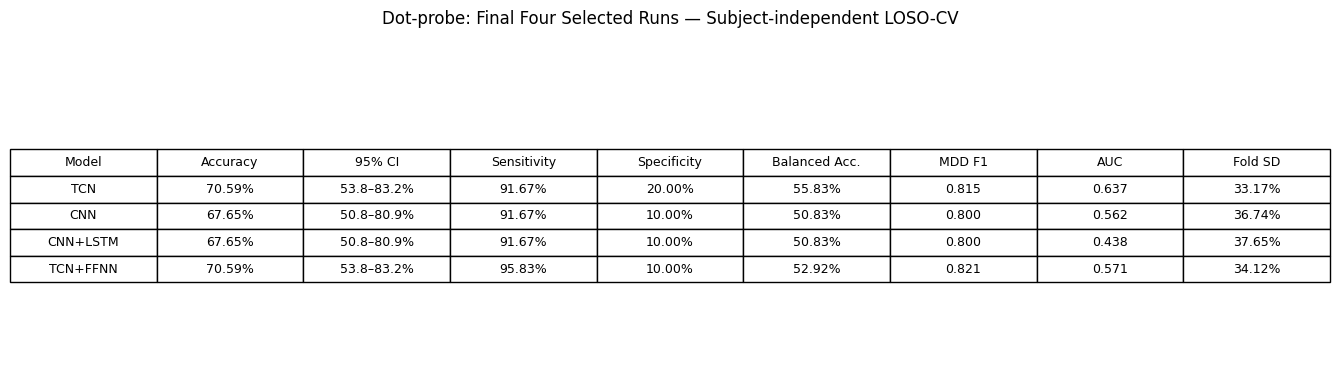

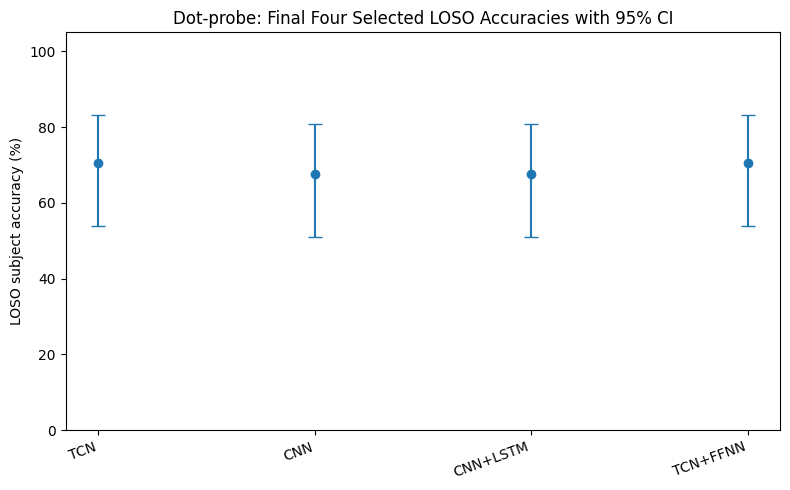


FINAL SOURCE CHECK


,model,source_run,LOSO_subject_accuracy,sensitivity_MDD,specificity_HC,balanced_accuracy,F1_MDD,subject_ROC_AUC
0,TCN,TCN_2,0.705882,0.916667,0.2,0.558333,0.814815,0.637500
1,CNN,CNN,0.676471,0.916667,0.1,0.508333,0.800000,0.562500
2,CNN+LSTM,CNN+LSTM_2,0.676471,0.916667,0.1,0.508333,0.800000,0.437500
3,TCN+FFNN,TCN+FFNN_2,0.705882,0.958333,0.1,0.529167,0.821429,0.570833


,Model,Accuracy,95% CI,Sensitivity,Specificity,Balanced Acc.,MDD F1,AUC,Fold SD
0,TCN,70.59%,53.8–83.2%,91.67%,20.00%,55.83%,0.815,0.637,33.17%
1,CNN,67.65%,50.8–80.9%,91.67%,10.00%,50.83%,0.800,0.562,36.74%
2,CNN+LSTM,67.65%,50.8–80.9%,91.67%,10.00%,50.83%,0.800,0.438,37.65%
3,TCN+FFNN,70.59%,53.8–83.2%,95.83%,10.00%,52.92%,0.821,0.571,34.12%



Saved CSV: /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_Final4_v3_Main/DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_REVIEWER_TABLE.csv
Saved table PNG: /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_Final4_v3_Main/DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_REVIEWER_TABLE.png
Saved accuracy-CI PNG: /kaggle/working/LOSO_Q1_dotprobe/model_results/DotProbe_Final4_v3_Main/DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_ACCURACY_CI.png


In [15]:
# ======================================================================
# FINAL FOUR-MODEL COMBINED REVIEWER TABLE
#
# IMPORTANT:
# Read the EXACT runs I want:
#
# TCN        <- TCN_2
# CNN        <- CNN
# CNN+LSTM   <- CNN_LSTM_2
# TCN+FFNN   <- TCN_FFNN_2
#
# The left side is the manuscript/display name.
# The right side is the actual Kaggle result folder/model name.
# ======================================================================

FINAL4_DIR = (
    Path(RESULTS_ROOT)
    /
    "DotProbe_Final4_v3_Main"
)

FINAL4_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ======================================================================
# EXACT MODEL RUNS TO USE
# ======================================================================

SELECTED_MODEL_RUNS = {
    "TCN": "TCN_2",
    "CNN": "CNN",
    "CNN+LSTM": "CNN+LSTM_2",
    "TCN+FFNN": "TCN+FFNN_2",
}


# Optional external files.
# These are only needed if /kaggle/working was lost.
#
# Keys here are the ACTUAL source run names.
EXTERNAL_DP3_SUMMARIES = {
    "TCN_2": None,
    "CNN": None,
    "CNN+LSTM_2": None,
    "TCN+FFNN_2": None,
}

EXTERNAL_DP3_FOLDS = {
    "TCN_2": None,
    "CNN": None,
    "CNN+LSTM_2": None,
    "TCN+FFNN_2": None,
}


# ======================================================================
# HELPER — RECONSTRUCT SUMMARY FROM FOLD CSV
# ======================================================================

def selected_summary_from_folds(
    fold_path,
    display_name
):
    d = pd.read_csv(
        fold_path
    )

    required = {
        "label",
        "subject_pred",
        "subject_prob",
        "window_accuracy",
        "subject_correct",
    }

    missing = required.difference(
        d.columns
    )

    if missing:
        raise ValueError(
            f"{fold_path} missing columns: "
            f"{sorted(missing)}"
        )


    yt = d[
        "label"
    ].to_numpy(
        dtype=int
    )

    yp = d[
        "subject_pred"
    ].to_numpy(
        dtype=int
    )

    pr = d[
        "subject_prob"
    ].to_numpy(
        dtype=float
    )


    tn, fp, fn, tp = confusion_matrix(
        yt,
        yp,
        labels=[
            0,
            1
        ]
    ).ravel()


    n = len(
        yt
    )

    n_mdd = int(
        tp + fn
    )

    n_hc = int(
        tn + fp
    )


    acc_ci = dp3_wilson(
        tp + tn,
        n
    )

    sens_ci = dp3_wilson(
        tp,
        n_mdd
    )

    spec_ci = dp3_wilson(
        tn,
        n_hc
    )


    return pd.DataFrame(
        [
            {
                "model":
                    display_name,

                "paradigm":
                    "Dot-probe",

                "n_subjects":
                    int(
                        n
                    ),

                "n_MDD":
                    n_mdd,

                "n_HC":
                    n_hc,


                "LOSO_subject_accuracy":
                    float(
                        (
                            tp
                            +
                            tn
                        )
                        /
                        n
                    ),

                "accuracy_CI95_low":
                    acc_ci[
                        0
                    ],

                "accuracy_CI95_high":
                    acc_ci[
                        1
                    ],


                "sensitivity_MDD":
                    float(
                        tp
                        /
                        n_mdd
                    )
                    if n_mdd
                    else np.nan,

                "sensitivity_CI95_low":
                    sens_ci[
                        0
                    ],

                "sensitivity_CI95_high":
                    sens_ci[
                        1
                    ],


                "specificity_HC":
                    float(
                        tn
                        /
                        n_hc
                    )
                    if n_hc
                    else np.nan,

                "specificity_CI95_low":
                    spec_ci[
                        0
                    ],

                "specificity_CI95_high":
                    spec_ci[
                        1
                    ],


                "balanced_accuracy":
                    float(
                        balanced_accuracy_score(
                            yt,
                            yp
                        )
                    ),


                "precision_MDD":
                    float(
                        precision_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),


                "F1_MDD":
                    float(
                        f1_score(
                            yt,
                            yp,
                            pos_label=1,
                            zero_division=0
                        )
                    ),


                "macro_F1":
                    float(
                        f1_score(
                            yt,
                            yp,
                            average="macro",
                            zero_division=0
                        )
                    ),


                "subject_ROC_AUC":
                    (
                        float(
                            roc_auc_score(
                                yt,
                                pr
                            )
                        )
                        if len(
                            np.unique(
                                yt
                            )
                        ) == 2
                        else np.nan
                    ),


                "mean_subject_prob_HC":
                    float(
                        np.mean(
                            pr[
                                yt == 0
                            ]
                        )
                    ),


                "mean_subject_prob_MDD":
                    float(
                        np.mean(
                            pr[
                                yt == 1
                            ]
                        )
                    ),


                "heldout_window_accuracy_mean":
                    float(
                        d[
                            "window_accuracy"
                        ].mean()
                    ),


                "heldout_window_accuracy_SD":
                    float(
                        d[
                            "window_accuracy"
                        ].std(
                            ddof=1
                        )
                    ),


                "subject_correct_indicator_SD":
                    float(
                        d[
                            "subject_correct"
                        ].std(
                            ddof=1
                        )
                    ),


                "TN_subjects":
                    int(
                        tn
                    ),

                "FP_subjects":
                    int(
                        fp
                    ),

                "FN_subjects":
                    int(
                        fn
                    ),

                "TP_subjects":
                    int(
                        tp
                    ),
            }
        ]
    )


# ======================================================================
# GET EXACT PATH FOR A SELECTED RUN
# ======================================================================

def selected_current_paths(
    source_name
):
    safe = dp3_safe_name(
        source_name
    )

    model_dir = (
        DP3_ROOT
        /
        safe
    )

    summary_path = (
        model_dir
        /
        f"{safe}_LOSO_summary.csv"
    )

    fold_path = (
        model_dir
        /
        f"{safe}_LOSO_folds.csv"
    )

    return (
        summary_path,
        fold_path
    )


# ======================================================================
# LOAD ONLY THE FOUR SELECTED RUNS
# ======================================================================

summary_rows = []

resolved_fold_paths = {}

missing_models = []


print(
    "\n"
    +
    "=" * 80
)

print(
    "SELECTED DOT-PROBE RUNS"
)

print(
    "=" * 80
)


for display_name, source_name in SELECTED_MODEL_RUNS.items():

    print(
        f"\n{display_name} <- {source_name}"
    )


    current_summary, current_folds = selected_current_paths(
        source_name
    )


    summary = None

    fold_path = None


    # ==========================================================
    # PRIORITY 1 — CURRENT /kaggle/working SUMMARY
    # ==========================================================

    if current_summary.exists():

        print(
            "  Using summary:"
        )

        print(
            " ",
            current_summary
        )

        summary = pd.read_csv(
            current_summary
        )


        if current_folds.exists():

            fold_path = current_folds


    # ==========================================================
    # PRIORITY 2 — EXTERNAL SUMMARY
    # ==========================================================

    elif EXTERNAL_DP3_SUMMARIES.get(
        source_name
    ):

        ext_summary = Path(
            EXTERNAL_DP3_SUMMARIES[
                source_name
            ]
        )


        if ext_summary.exists():

            print(
                "  Using external summary:"
            )

            print(
                " ",
                ext_summary
            )

            summary = pd.read_csv(
                ext_summary
            )


    # ==========================================================
    # PRIORITY 3 — RECONSTRUCT FROM CURRENT FOLD CSV
    # ==========================================================

    if summary is None:

        candidate_fold = None


        if current_folds.exists():

            candidate_fold = current_folds


        elif EXTERNAL_DP3_FOLDS.get(
            source_name
        ):

            ext_fold = Path(
                EXTERNAL_DP3_FOLDS[
                    source_name
                ]
            )


            if ext_fold.exists():

                candidate_fold = ext_fold


        if candidate_fold is not None:

            tmp = pd.read_csv(
                candidate_fold
            )


            expected_n = len(
                np.unique(
                    groups
                )
            )


            actual_n = tmp[
                "subject"
            ].astype(
                str
            ).nunique()


            print(
                f"  Fold CSV subjects: "
                f"{actual_n}/{expected_n}"
            )


            if actual_n == expected_n:

                print(
                    "  Reconstructing summary from:"
                )

                print(
                    " ",
                    candidate_fold
                )


                summary = selected_summary_from_folds(
                    candidate_fold,
                    display_name
                )


                fold_path = candidate_fold


            else:

                print(
                    "  WARNING: fold CSV is incomplete."
                )


    # ==========================================================
    # NOTHING FOUND
    # ==========================================================

    if (
        summary is None
        or
        len(
            summary
        ) == 0
    ):

        missing_models.append(
            display_name
        )


        print(
            f"  !!! RESULT NOT FOUND FOR "
            f"{display_name} <- {source_name}"
        )


        continue


    # ==========================================================
    # FORCE MANUSCRIPT DISPLAY NAME
    #
    # e.g. folder = TCN_2
    # displayed model = TCN
    # ==========================================================

    row = summary.iloc[
        0
    ].to_dict()


    row[
        "model"
    ] = display_name


    row[
        "source_run"
    ] = source_name


    summary_rows.append(
        row
    )


    resolved_fold_paths[
        display_name
    ] = fold_path


    print(
        "  Accuracy:",
        f"{100*float(row['LOSO_subject_accuracy']):.2f}%"
    )


    print(
        "  AUC:",
        f"{float(row['subject_ROC_AUC']):.3f}"
    )


# ======================================================================
# BUILD FINAL TABLE
# ======================================================================

combined4 = pd.DataFrame(
    summary_rows
)


if missing_models:

    print(
        "\nMissing selected models:",
        missing_models
    )


if len(
    combined4
):

    model_order = list(
        SELECTED_MODEL_RUNS.keys()
    )


    order_map = {
        model: i
        for i, model in enumerate(
            model_order
        )
    }


    combined4[
        "_order"
    ] = combined4[
        "model"
    ].map(
        order_map
    )


    combined4 = (
        combined4
        .sort_values(
            "_order"
        )
        .drop(
            columns=[
                "_order"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # ==========================================================
    # SAVE RAW COMBINED CSV
    # ==========================================================

    csv_path = (
        FINAL4_DIR
        /
        "DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_REVIEWER_TABLE.csv"
    )


    combined4.to_csv(
        csv_path,
        index=False
    )


    # ==========================================================
    # HUMAN-READABLE TABLE
    # ==========================================================

    human = pd.DataFrame(
        {
            "Model":
                combined4[
                    "model"
                ],


            "Accuracy":
                (
                    100
                    *
                    combined4[
                        "LOSO_subject_accuracy"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),


            "95% CI":
                [
                    f"{100*l:.1f}–{100*h:.1f}%"
                    for l, h in zip(
                        combined4[
                            "accuracy_CI95_low"
                        ],
                        combined4[
                            "accuracy_CI95_high"
                        ]
                    )
                ],


            "Sensitivity":
                (
                    100
                    *
                    combined4[
                        "sensitivity_MDD"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),


            "Specificity":
                (
                    100
                    *
                    combined4[
                        "specificity_HC"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),


            "Balanced Acc.":
                (
                    100
                    *
                    combined4[
                        "balanced_accuracy"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),


            "MDD F1":
                combined4[
                    "F1_MDD"
                ].map(
                    lambda x:
                    f"{x:.3f}"
                ),


            "AUC":
                combined4[
                    "subject_ROC_AUC"
                ].map(
                    lambda x:
                    f"{x:.3f}"
                ),


            "Fold SD":
                (
                    100
                    *
                    combined4[
                        "heldout_window_accuracy_SD"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),
        }
    )


    # ==========================================================
    # TABLE PNG
    # ==========================================================

    fig, ax = plt.subplots(
        figsize=(
            13.5,
            4.0
        )
    )


    ax.axis(
        "off"
    )


    tab = ax.table(
        cellText=human.values,
        colLabels=human.columns,
        loc="center",
        cellLoc="center"
    )


    tab.auto_set_font_size(
        False
    )


    tab.set_fontsize(
        9
    )


    tab.scale(
        1,
        1.5
    )


    ax.set_title(
        "Dot-probe: Final Four Selected Runs — Subject-independent LOSO-CV",
        pad=20
    )


    plt.tight_layout()


    table_png = (
        FINAL4_DIR
        /
        "DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_REVIEWER_TABLE.png"
    )


    plt.savefig(
        table_png,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    # ==========================================================
    # ACCURACY + 95% CI
    # ==========================================================

    acc = combined4[
        "LOSO_subject_accuracy"
    ].to_numpy(
        dtype=float
    )


    lo = combined4[
        "accuracy_CI95_low"
    ].to_numpy(
        dtype=float
    )


    hi = combined4[
        "accuracy_CI95_high"
    ].to_numpy(
        dtype=float
    )


    xpos = np.arange(
        len(
            combined4
        )
    )


    plt.figure(
        figsize=(
            8,
            5
        )
    )


    plt.errorbar(
        xpos,
        100
        *
        acc,

        yerr=100
        *
        np.vstack(
            [
                acc-lo,
                hi-acc
            ]
        ),

        fmt="o",
        capsize=5
    )


    plt.xticks(
        xpos,
        combined4[
            "model"
        ],
        rotation=20,
        ha="right"
    )


    plt.ylabel(
        "LOSO subject accuracy (%)"
    )


    plt.ylim(
        0,
        105
    )


    plt.title(
        "Dot-probe: Final Four Selected LOSO Accuracies with 95% CI"
    )


    plt.tight_layout()


    ci_png = (
        FINAL4_DIR
        /
        "DOTPROBE_FINAL_4_SELECTED_RUNS_LOSO_ACCURACY_CI.png"
    )


    plt.savefig(
        ci_png,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    # ==========================================================
    # FINAL CHECK — SHOW EXACT SOURCE USED
    # ==========================================================

    print(
        "\n"
        +
        "=" * 80
    )

    print(
        "FINAL SOURCE CHECK"
    )

    print(
        "=" * 80
    )


    display(
        combined4[
            [
                "model",
                "source_run",
                "LOSO_subject_accuracy",
                "sensitivity_MDD",
                "specificity_HC",
                "balanced_accuracy",
                "F1_MDD",
                "subject_ROC_AUC",
            ]
        ]
    )


    display(
        human
    )


    print(
        "\nSaved CSV:",
        csv_path
    )


    print(
        "Saved table PNG:",
        table_png
    )


    print(
        "Saved accuracy-CI PNG:",
        ci_png
    )


else:

    print(
        "No selected model results were found."
    )

## Reviewer-3 — dot-probe biomarker / biological-significance analysis

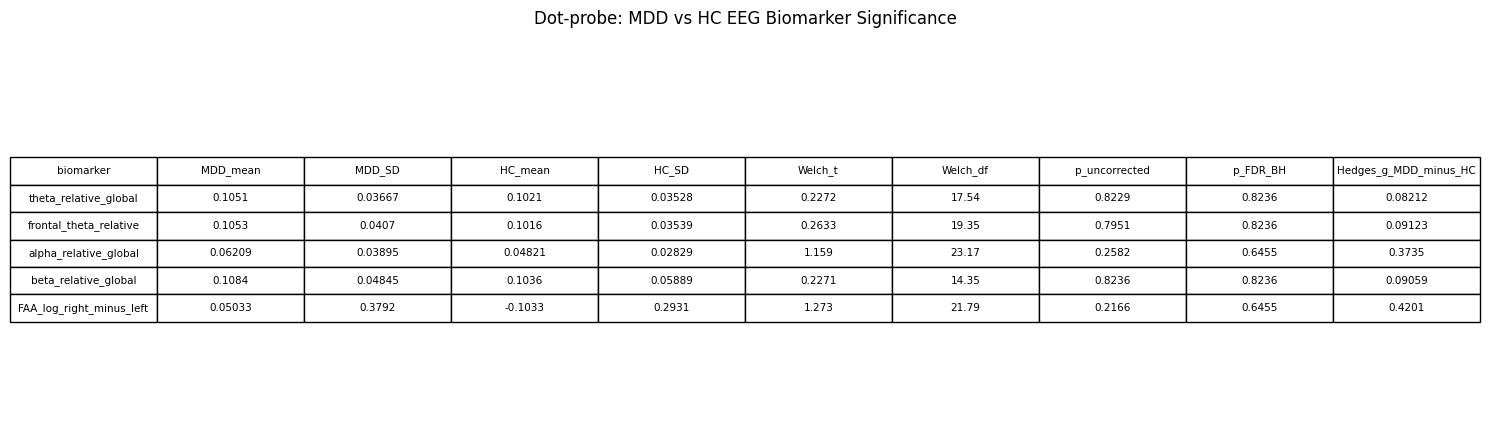

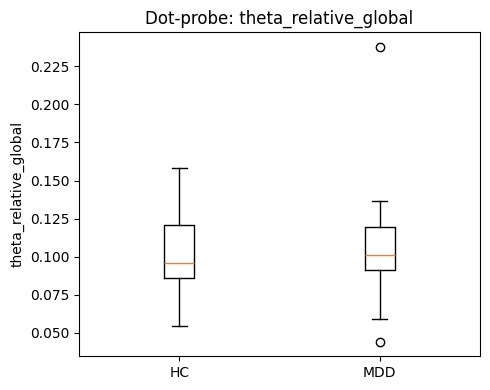

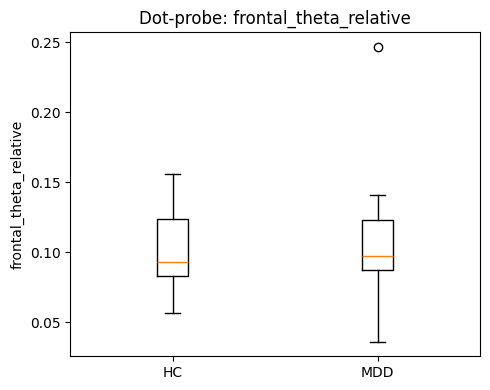

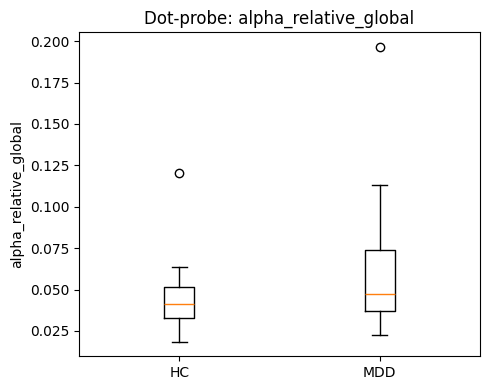

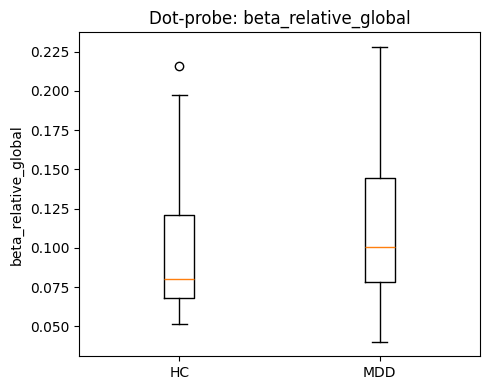

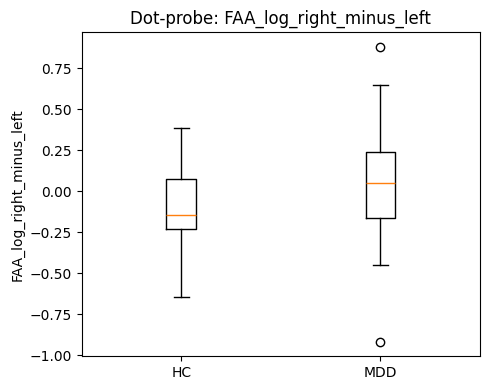

Left frontal: ['E12', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E32', 'E33']
Right frontal: ['E1', 'E2', 'E3', 'E4', 'E5', 'E8', 'E9', 'E10', 'E14', 'E117', 'E118', 'E122', 'E123', 'E124']
Saved subject biomarkers: /kaggle/working/LOSO_Q1_dotprobe/model_results/Reviewer3_DotProbe_Biomarkers_v3/DOTPROBE_subject_level_EEG_biomarkers.csv
Saved group statistics: /kaggle/working/LOSO_Q1_dotprobe/model_results/Reviewer3_DotProbe_Biomarkers_v3/DOTPROBE_MDD_vs_HC_biomarker_statistics.csv


,biomarker,n_MDD,n_HC,MDD_mean,MDD_SD,HC_mean,HC_SD,mean_difference_MDD_minus_HC,mean_difference_CI95_low,mean_difference_CI95_high,Welch_t,Welch_df,p_uncorrected,Hedges_g_MDD_minus_HC,p_FDR_BH,FDR_significant_0.05
0,theta_relative_global,24,10,0.105135,0.036668,0.102083,0.035278,0.003052,-0.025226,0.031329,0.227154,17.535914,0.822931,0.082121,0.823570,False
1,frontal_theta_relative,24,10,0.105295,0.040698,0.101626,0.035393,0.003670,-0.025468,0.032808,0.263297,19.350440,0.795105,0.091227,0.823570,False
2,alpha_relative_global,24,10,0.062086,0.038946,0.048213,0.028291,0.013873,-0.010875,0.038621,1.159138,23.170848,0.258206,0.373485,0.645516,False
3,beta_relative_global,24,10,0.108390,0.048454,0.103602,0.058885,0.004788,-0.040332,0.049908,0.227073,14.347621,0.823570,0.090593,0.823570,False
4,FAA_log_right_minus_left,24,10,0.050331,0.379184,-0.103317,0.293061,0.153648,-0.096904,0.404200,1.272502,21.786829,0.216608,0.420141,0.645516,False


In [16]:
# ======================================================================
# REVIEWER-3 — DOT-PROBE EEG BIOMARKER / BIOLOGICAL SIGNIFICANCE
#
# Task-related EEG biomarkers:
#   relative theta 4–8 Hz
#   relative alpha 8–13 Hz
#   relative beta 13–30 Hz
#   broad frontal relative theta
#   broad frontal alpha asymmetry
#
# The denominator for relative power is 1–40 Hz.
# ======================================================================

from scipy import signal, stats

BIO_DIR = (
    Path(RESULTS_ROOT)
    /
    "Reviewer3_DotProbe_Biomarkers_v3"
)

BIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Physiological analysis does not need all overlapping windows.
# These 64 windows are uniformly spread across each participant.
BIO_WINDOWS = min(
    64,
    MAX_WINDOWS_PER_SUBJECT
    if MAX_WINDOWS_PER_SUBJECT is not None
    else 64
)

BANDS = {
    "theta": (
        4.0,
        8.0
    ),

    "alpha": (
        8.0,
        13.0
    ),

    "beta": (
        13.0,
        30.0
    )
}

TOTAL_POWER_BAND = (
    1.0,
    40.0
)


def bio_channel_number(
    ch
):
    m = re.search(
        r"(\d{1,3})$",
        str(ch)
    )

    return (
        int(
            m.group(1)
        )
        if m
        else None
    )


def bio_frontal_sets(
    channels
):
    try:
        import mne

        montage = mne.channels.make_standard_montage(
            "GSN-HydroCel-128"
        )

        pos = montage.get_positions()[
            "ch_pos"
        ]

        rows = []

        for ch in channels:
            n = bio_channel_number(
                ch
            )

            key = (
                f"E{n}"
                if n is not None
                else None
            )

            if key in pos:
                x, y_coord, z = pos[
                    key
                ]

                rows.append(
                    [
                        str(ch),
                        n,
                        float(x),
                        float(y_coord),
                        float(z)
                    ]
                )

        geometry = pd.DataFrame(
            rows,
            columns=[
                "channel",
                "number",
                "x",
                "y",
                "z"
            ]
        )

        if len(
            geometry
        ) < 20:
            raise RuntimeError(
                "Too few channels matched HydroCel-128."
            )

        anterior = geometry[
            (
                geometry[
                    "y"
                ]
                >=
                geometry[
                    "y"
                ].quantile(
                    0.70
                )
            )
            &
            (
                geometry[
                    "z"
                ]
                >=
                geometry[
                    "z"
                ].quantile(
                    0.20
                )
            )
        ].copy()

        left = anterior.loc[
            anterior[
                "x"
            ]
            <
            0,
            "channel"
        ].tolist()

        right = anterior.loc[
            anterior[
                "x"
            ]
            >
            0,
            "channel"
        ].tolist()

        geometry.to_csv(
            BIO_DIR
            /
            "HydroCel128_channel_geometry.csv",
            index=False
        )

        anterior.to_csv(
            BIO_DIR
            /
            "broad_frontal_channel_geometry.csv",
            index=False
        )

        return left, right

    except Exception as exc:
        print(
            "FAA/frontal montage unavailable:",
            exc
        )

        return [], []


def bio_integrate(
    psd,
    freqs,
    lo,
    hi
):
    mask = (
        (
            freqs >= lo
        )
        &
        (
            freqs < hi
        )
    )

    if np.sum(
        mask
    ) < 2:
        return np.full(
            psd.shape[-1],
            np.nan,
            dtype=float
        )

    if hasattr(
        np,
        "trapezoid"
    ):
        return np.trapezoid(
            psd[
                mask
            ],
            freqs[
                mask
            ],
            axis=0
        )

    return np.trapz(
        psd[
            mask
        ],
        freqs[
            mask
        ],
        axis=0
    )


def bio_hedges_g(
    a,
    b
):
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    n1 = len(a)
    n2 = len(b)

    if (
        n1 < 2
        or
        n2 < 2
    ):
        return np.nan

    pooled = (
        (
            (
                n1 - 1
            )
            *
            np.var(
                a,
                ddof=1
            )
            +
            (
                n2 - 1
            )
            *
            np.var(
                b,
                ddof=1
            )
        )
        /
        (
            n1
            +
            n2
            -
            2
        )
    )

    if (
        pooled <= 0
        or
        not np.isfinite(
            pooled
        )
    ):
        return 0.0

    correction = (
        1
        -
        3
        /
        (
            4
            *
            (
                n1
                +
                n2
            )
            -
            9
        )
    )

    return float(
        correction
        *
        (
            np.mean(a)
            -
            np.mean(b)
        )
        /
        np.sqrt(
            pooled
        )
    )


def bio_welch_ci(
    a,
    b,
    alpha=0.05
):
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    n1 = len(a)
    n2 = len(b)

    v1 = np.var(
        a,
        ddof=1
    )

    v2 = np.var(
        b,
        ddof=1
    )

    term1 = v1 / n1
    term2 = v2 / n2

    se = np.sqrt(
        term1 + term2
    )

    diff = float(
        np.mean(a)
        -
        np.mean(b)
    )

    if (
        se == 0
        or
        not np.isfinite(
            se
        )
    ):
        return np.nan, diff, diff

    df = (
        (
            term1
            +
            term2
        )
        **
        2
        /
        (
            term1**2
            /
            (
                n1 - 1
            )
            +
            term2**2
            /
            (
                n2 - 1
            )
        )
    )

    crit = stats.t.ppf(
        1
        -
        alpha
        /
        2,
        df
    )

    return (
        float(df),
        float(
            diff
            -
            crit
            *
            se
        ),
        float(
            diff
            +
            crit
            *
            se
        )
    )


def bio_bh_fdr(
    p_values
):
    p = np.asarray(
        p_values,
        dtype=float
    )

    q = np.full_like(
        p,
        np.nan,
        dtype=float
    )

    valid = np.isfinite(
        p
    )

    if not np.any(
        valid
    ):
        return q

    pv = p[
        valid
    ]

    order = np.argsort(
        pv
    )

    ranked = pv[
        order
    ]

    adjusted = (
        ranked
        *
        len(
            ranked
        )
        /
        np.arange(
            1,
            len(
                ranked
            )
            +
            1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[
            ::-1
        ]
    )[
        ::-1
    ]

    adjusted = np.minimum(
        adjusted,
        1.0
    )

    restored = np.empty_like(
        adjusted
    )

    restored[
        order
    ] = adjusted

    q[
        valid
    ] = restored

    return q


left_frontal, right_frontal = bio_frontal_sets(
    channel_names
)

channel_index = {
    str(c): i
    for i, c in enumerate(
        channel_names
    )
}

left_idx = [
    channel_index[
        c
    ]
    for c in left_frontal
    if c in channel_index
]

right_idx = [
    channel_index[
        c
    ]
    for c in right_frontal
    if c in channel_index
]


pd.DataFrame(
    {
        "hemisphere":
            (
                [
                    "left"
                ]
                *
                len(
                    left_frontal
                )
                +
                [
                    "right"
                ]
                *
                len(
                    right_frontal
                )
            ),
        "channel":
            left_frontal
            +
            right_frontal
    }
).to_csv(
    BIO_DIR
    /
    "broad_frontal_channel_sets.csv",
    index=False
)


bio_rows = []


for subject in np.unique(
    groups
):

    idx = np.where(
        groups
        ==
        subject
    )[0]


    if len(
        idx
    ) > BIO_WINDOWS:

        idx = idx[
            np.linspace(
                0,
                len(idx)
                -
                1,
                BIO_WINDOWS,
                dtype=int
            )
        ]


    Xi = X[
        idx
    ].astype(
        np.float32
    ).copy()


    channel_mean = np.nanmean(
        Xi.reshape(
            -1,
            Xi.shape[
                -1
            ]
        ),
        axis=0
    )


    channel_mean = np.where(
        np.isfinite(
            channel_mean
        ),
        channel_mean,
        0.0
    )


    for c in range(
        Xi.shape[
            -1
        ]
    ):

        bad = ~np.isfinite(
            Xi[
                ...,
                c
            ]
        )

        if np.any(
            bad
        ):
            Xi[
                ...,
                c
            ][
                bad
            ] = channel_mean[
                c
            ]


    # DC removal for PSD only; do not z-score away spectral power.
    Xi = (
        Xi
        -
        Xi.mean(
            axis=1,
            keepdims=True
        )
    )


    freqs, pxx = signal.welch(
        Xi,
        fs=FS,
        axis=1,
        nperseg=WINDOW_SIZE,
        detrend="constant",
        scaling="density"
    )


    mean_psd = pxx.mean(
        axis=0
    )


    total_power = bio_integrate(
        mean_psd,
        freqs,
        TOTAL_POWER_BAND[
            0
        ],
        TOTAL_POWER_BAND[
            1
        ]
    )


    total_power = np.where(
        (
            np.isfinite(
                total_power
            )
        )
        &
        (
            total_power > 1e-20
        ),
        total_power,
        np.nan
    )


    abs_power = {}
    rel_power = {}


    for band_name, (
        lo,
        hi
    ) in BANDS.items():

        abs_power[
            band_name
        ] = bio_integrate(
            mean_psd,
            freqs,
            lo,
            hi
        )

        rel_power[
            band_name
        ] = (
            abs_power[
                band_name
            ]
            /
            total_power
        )


    label = int(
        y[
            groups
            ==
            subject
        ][0]
    )


    row = {
        "subject":
            str(subject),

        "label":
            label,

        "diagnosis":
            LABEL_NAMES[
                label
            ],

        "n_biomarker_windows":
            int(
                len(idx)
            ),

        "theta_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "theta"
                    ]
                )
            ),

        "alpha_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "alpha"
                    ]
                )
            ),

        "beta_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "beta"
                    ]
                )
            ),

        "theta_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "theta"
                    ]
                )
            ),

        "alpha_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "alpha"
                    ]
                )
            ),

        "beta_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "beta"
                    ]
                )
            )
    }


    if (
        left_idx
        and
        right_idx
    ):

        frontal_idx = (
            left_idx
            +
            right_idx
        )

        row[
            "frontal_theta_relative"
        ] = float(
            np.nanmean(
                rel_power[
                    "theta"
                ][
                    frontal_idx
                ]
            )
        )

        left_alpha = float(
            np.nanmean(
                abs_power[
                    "alpha"
                ][
                    left_idx
                ]
            )
        )

        right_alpha = float(
            np.nanmean(
                abs_power[
                    "alpha"
                ][
                    right_idx
                ]
            )
        )

        row[
            "FAA_log_right_minus_left"
        ] = float(
            np.log(
                right_alpha
                +
                1e-20
            )
            -
            np.log(
                left_alpha
                +
                1e-20
            )
        )

    else:

        row[
            "frontal_theta_relative"
        ] = np.nan

        row[
            "FAA_log_right_minus_left"
        ] = np.nan


    bio_rows.append(
        row
    )


biomarkers = pd.DataFrame(
    bio_rows
)


bio_csv = (
    BIO_DIR
    /
    "DOTPROBE_subject_level_EEG_biomarkers.csv"
)

biomarkers.to_csv(
    bio_csv,
    index=False
)


PRIMARY_BIOMARKERS = [
    "theta_relative_global",
    "frontal_theta_relative",
    "alpha_relative_global",
    "beta_relative_global",
    "FAA_log_right_minus_left",
]


stats_rows = []


for metric in PRIMARY_BIOMARKERS:

    mdd = (
        biomarkers.loc[
            biomarkers[
                "label"
            ]
            ==
            1,
            metric
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    hc = (
        biomarkers.loc[
            biomarkers[
                "label"
            ]
            ==
            0,
            metric
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )

    if (
        len(mdd) < 2
        or
        len(hc) < 2
    ):
        continue


    t_stat, p_value = stats.ttest_ind(
        mdd,
        hc,
        equal_var=False,
        nan_policy="omit"
    )


    welch_df, ci_low, ci_high = bio_welch_ci(
        mdd,
        hc
    )


    stats_rows.append(
        {
            "biomarker":
                metric,

            "n_MDD":
                int(
                    len(mdd)
                ),

            "n_HC":
                int(
                    len(hc)
                ),

            "MDD_mean":
                float(
                    np.mean(mdd)
                ),

            "MDD_SD":
                float(
                    np.std(
                        mdd,
                        ddof=1
                    )
                ),

            "HC_mean":
                float(
                    np.mean(hc)
                ),

            "HC_SD":
                float(
                    np.std(
                        hc,
                        ddof=1
                    )
                ),

            "mean_difference_MDD_minus_HC":
                float(
                    np.mean(mdd)
                    -
                    np.mean(hc)
                ),

            "mean_difference_CI95_low":
                ci_low,

            "mean_difference_CI95_high":
                ci_high,

            "Welch_t":
                float(
                    t_stat
                ),

            "Welch_df":
                welch_df,

            "p_uncorrected":
                float(
                    p_value
                ),

            "Hedges_g_MDD_minus_HC":
                bio_hedges_g(
                    mdd,
                    hc
                )
        }
    )


bio_stats = pd.DataFrame(
    stats_rows
)


if len(
    bio_stats
):
    bio_stats[
        "p_FDR_BH"
    ] = bio_bh_fdr(
        bio_stats[
            "p_uncorrected"
        ].to_numpy(
            dtype=float
        )
    )

    bio_stats[
        "FDR_significant_0.05"
    ] = (
        bio_stats[
            "p_FDR_BH"
        ]
        <
        0.05
    )


stats_csv = (
    BIO_DIR
    /
    "DOTPROBE_MDD_vs_HC_biomarker_statistics.csv"
)

bio_stats.to_csv(
    stats_csv,
    index=False
)


if len(
    bio_stats
):

    shown = bio_stats[
        [
            "biomarker",
            "MDD_mean",
            "MDD_SD",
            "HC_mean",
            "HC_SD",
            "Welch_t",
            "Welch_df",
            "p_uncorrected",
            "p_FDR_BH",
            "Hedges_g_MDD_minus_HC"
        ]
    ].copy()


    for col in shown.columns[
        1:
    ]:
        shown[
            col
        ] = shown[
            col
        ].map(
            lambda x:
            f"{x:.4g}"
            if pd.notna(x)
            else ""
        )


    fig, ax = plt.subplots(
        figsize=(
            15,
            4.5
        )
    )

    ax.axis(
        "off"
    )

    table = ax.table(
        cellText=shown.values,
        colLabels=shown.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(
        False
    )

    table.set_fontsize(
        7.5
    )

    table.scale(
        1,
        1.5
    )

    ax.set_title(
        "Dot-probe: MDD vs HC EEG Biomarker Significance",
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        BIO_DIR
        /
        "DOTPROBE_MDD_vs_HC_biomarker_statistics.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


for metric in PRIMARY_BIOMARKERS:

    if (
        metric not in biomarkers.columns
        or
        biomarkers[
            metric
        ].isna().all()
    ):
        continue

    hc_values = biomarkers.loc[
        biomarkers[
            "label"
        ]
        ==
        0,
        metric
    ].dropna()

    mdd_values = biomarkers.loc[
        biomarkers[
            "label"
        ]
        ==
        1,
        metric
    ].dropna()

    plt.figure(
        figsize=(
            5,
            4
        )
    )

    plt.boxplot(
        [
            hc_values,
            mdd_values
        ],
        tick_labels=[
            "HC",
            "MDD"
        ]
    )

    plt.ylabel(
        metric
    )

    plt.title(
        f"Dot-probe: {metric}"
    )

    plt.tight_layout()

    plt.savefig(
        BIO_DIR
        /
        f"DOTPROBE_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


print("Left frontal:", left_frontal)
print("Right frontal:", right_frontal)
print("Saved subject biomarkers:", bio_csv)
print("Saved group statistics:", stats_csv)

display(
    bio_stats
)

## Reviewer-3 — final-four model probability ↔ biomarker associations

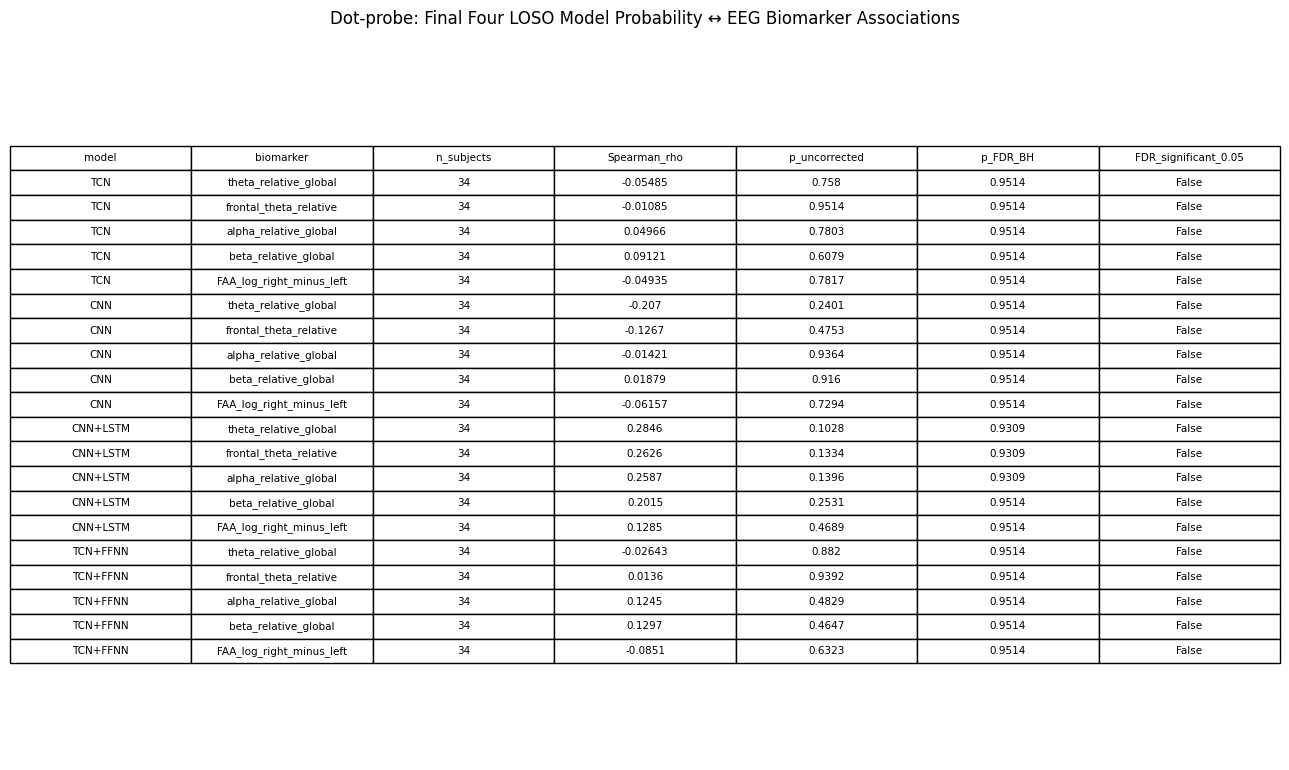

,model,biomarker,n_subjects,Spearman_rho,p_uncorrected,p_FDR_BH,FDR_significant_0.05
0,TCN,theta_relative_global,34,-0.054851,0.758004,0.951447,False
1,TCN,frontal_theta_relative,34,-0.010848,0.951447,0.951447,False
2,TCN,alpha_relative_global,34,0.049656,0.780333,0.951447,False
3,TCN,beta_relative_global,34,0.091215,0.607919,0.951447,False
4,TCN,FAA_log_right_minus_left,34,-0.049351,0.781652,0.951447,False
5,CNN,theta_relative_global,34,-0.207028,0.240075,0.951447,False
6,CNN,frontal_theta_relative,34,-0.126662,0.475341,0.951447,False
7,CNN,alpha_relative_global,34,-0.014209,0.936429,0.951447,False
8,CNN,beta_relative_global,34,0.018793,0.915986,0.951447,False
9,CNN,FAA_log_right_minus_left,34,-0.061574,0.729393,0.951447,False


Saved: /kaggle/working/LOSO_Q1_dotprobe/model_results/Reviewer3_DotProbe_Model_Biomarker_Associations_v3/DOTPROBE_FINAL4_model_probability_biomarker_associations.csv


In [17]:
# ======================================================================
# REVIEWER-3 — FINAL FOUR MODEL PROBABILITY ↔ BIOMARKER ASSOCIATIONS
#
# Corroborative association only; not causal feature attribution.
# ======================================================================

ASSOC_DIR = (
    Path(RESULTS_ROOT)
    /
    "Reviewer3_DotProbe_Model_Biomarker_Associations_v3"
)

ASSOC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

association_rows = []


for model_name in FINAL_DOTPROBE_MODELS:

    fold_path = resolved_fold_paths.get(
        model_name
    )


    if (
        fold_path is None
        or
        not Path(
            fold_path
        ).exists()
    ):

        _, current_fold = dp3_current_paths(
            model_name
        )

        if current_fold.exists():
            fold_path = current_fold

        elif EXTERNAL_DP3_FOLDS.get(
            model_name
        ):
            p = Path(
                EXTERNAL_DP3_FOLDS[
                    model_name
                ]
            )

            if p.exists():
                fold_path = p


    if (
        fold_path is None
        or
        not Path(
            fold_path
        ).exists()
    ):
        print(
            f"{model_name}: fold CSV unavailable; skipping."
        )

        continue


    folds = pd.read_csv(
        fold_path
    )


    model_subjects = folds[
        [
            "subject",
            "subject_prob"
        ]
    ].copy()


    model_subjects[
        "subject"
    ] = model_subjects[
        "subject"
    ].astype(
        str
    )


    model_subjects = model_subjects.rename(
        columns={
            "subject_prob":
                "model_MDD_probability"
        }
    )


    merged = biomarkers.copy()

    merged[
        "subject"
    ] = merged[
        "subject"
    ].astype(
        str
    )


    merged = merged.merge(
        model_subjects,
        on="subject",
        how="inner"
    )


    for metric in PRIMARY_BIOMARKERS:

        d = merged[
            [
                "model_MDD_probability",
                metric
            ]
        ].dropna()

        if len(d) < 5:
            continue

        rho, p_value = stats.spearmanr(
            d[
                "model_MDD_probability"
            ],
            d[
                metric
            ]
        )

        association_rows.append(
            {
                "model":
                    model_name,

                "biomarker":
                    metric,

                "n_subjects":
                    int(
                        len(d)
                    ),

                "Spearman_rho":
                    float(
                        rho
                    ),

                "p_uncorrected":
                    float(
                        p_value
                    )
            }
        )


associations = pd.DataFrame(
    association_rows
)


if len(
    associations
):

    associations[
        "p_FDR_BH"
    ] = bio_bh_fdr(
        associations[
            "p_uncorrected"
        ].to_numpy(
            dtype=float
        )
    )


    associations[
        "FDR_significant_0.05"
    ] = (
        associations[
            "p_FDR_BH"
        ]
        <
        0.05
    )


    assoc_csv = (
        ASSOC_DIR
        /
        "DOTPROBE_FINAL4_model_probability_biomarker_associations.csv"
    )


    associations.to_csv(
        assoc_csv,
        index=False
    )


    shown = associations.copy()

    for col in [
        "Spearman_rho",
        "p_uncorrected",
        "p_FDR_BH"
    ]:

        shown[
            col
        ] = shown[
            col
        ].map(
            lambda x:
            f"{x:.4g}"
            if pd.notna(x)
            else ""
        )


    fig, ax = plt.subplots(
        figsize=(
            13,
            max(
                4,
                1.0
                +
                0.34
                *
                len(shown)
            )
        )
    )

    ax.axis(
        "off"
    )

    table = ax.table(
        cellText=shown.values,
        colLabels=shown.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(
        False
    )

    table.set_fontsize(
        7.5
    )

    table.scale(
        1,
        1.25
    )

    ax.set_title(
        "Dot-probe: Final Four LOSO Model Probability ↔ EEG Biomarker Associations",
        pad=18
    )

    plt.tight_layout()

    assoc_png = (
        ASSOC_DIR
        /
        "DOTPROBE_FINAL4_model_probability_biomarker_associations.png"
    )

    plt.savefig(
        assoc_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    display(
        associations
    )

    print(
        "Saved:",
        assoc_csv
    )

else:
    print(
        "No model-biomarker associations could be calculated yet."
    )